# E-Commerce Delivery Time Prediction

## Assignment 2: Model to Web Application

### Business Problem
The objective of this project is to develop a multiple linear regression model
that predicts the delivery time of an e-commerce order based on order,
warehouse, courier, traffic, and shipping-related characteristics.

The target variable is Delivery_Time_Hours.

In [1]:
# Import pandas for loading, cleaning, and analysing tabular data
import pandas as pd

# Import numpy for numerical calculations and handling numerical values
import numpy as np

# Import matplotlib for creating graphs and visualisations
import matplotlib.pyplot as plt

# Import seaborn for creating statistical plots
import seaborn as sns

# Import statsmodels for regression modelling and statistical diagnostics
import statsmodels.api as sm

# Import warnings so unnecessary warning messages can be hidden
import warnings

# Ignore warning messages to keep notebook output cleaner
warnings.filterwarnings("ignore")

In [2]:
# Load the CSV dataset into a pandas DataFrame called df
# pd.read_csv() is used because our dataset is stored as a .csv file
df = pd.read_csv("ecommerce_delivery_unclean_data.csv")

# Display the first 5 rows to confirm that the dataset loaded correctly
df.head()

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
0,ORD100001,Electronics,Standard,2650.0,0.82,15.0,1,1.41,1.50,1.00,11.39
1,ORD100002,Beauty,Same-Day,1433.0,0.44,49.7,1,1.35,1.93,1.61,6.71
2,ORD100003,Fashion,Express,1886.0,0.88,84.5,1,1.88,2.36,2.22,18.63
3,ORD100004,Books,Standard,1369.0,1.55,119.2,1,2.42,2.79,2.83,31.81
4,ORD100005,Home & Kitchen,Same-Day,2532.0,2.71,153.9,1,2.35,3.22,3.44,24.01


In [3]:
# Display the number of rows and columns in the dataset
# Output format is: (number of rows, number of columns)
df.shape

(404, 11)

In [4]:
# Display detailed information about the dataset
# This shows:
# - Column names
# - Number of non-null observations
# - Data type of each variable
# - Approximate memory usage
# This is useful for identifying missing values and incorrect data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    404 non-null    str    
 1   Product_Category            403 non-null    str    
 2   Shipping_Mode               403 non-null    str    
 3   Order_Value                 403 non-null    float64
 4   Package_Weight_Kg           403 non-null    float64
 5   Warehouse_Distance_Km       404 non-null    float64
 6   Items_in_Order              404 non-null    int64  
 7   Warehouse_Processing_Hours  403 non-null    float64
 8   Courier_Load_Index          404 non-null    float64
 9   Traffic_Index               403 non-null    float64
 10  Delivery_Time_Hours         403 non-null    float64
dtypes: float64(7), int64(1), str(3)
memory usage: 44.9 KB


In [5]:
# Display the first 5 observations in the dataset
# This helps us visually inspect the structure and values of the data
df.head()

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
0,ORD100001,Electronics,Standard,2650.0,0.82,15.0,1,1.41,1.50,1.00,11.39
1,ORD100002,Beauty,Same-Day,1433.0,0.44,49.7,1,1.35,1.93,1.61,6.71
2,ORD100003,Fashion,Express,1886.0,0.88,84.5,1,1.88,2.36,2.22,18.63
3,ORD100004,Books,Standard,1369.0,1.55,119.2,1,2.42,2.79,2.83,31.81
4,ORD100005,Home & Kitchen,Same-Day,2532.0,2.71,153.9,1,2.35,3.22,3.44,24.01


In [6]:
# Generate descriptive statistics for both numerical and categorical variables
# include="all" ensures that categorical variables are also included
# .T transposes the output to make the table easier to read
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,404,400,ORD100019,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,403,13,Electronics,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Shipping_Mode,403,11,Same-Day,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Value,403.0,NaN,NaN,NaN,6387.724566,3810.315161,-950.0,4654.0,6276.0,7821.0,68880.0
Package_Weight_Kg,403.0,NaN,NaN,NaN,3.78335,3.212804,-2.7,2.495,3.54,4.66,59.2
Warehouse_Distance_Km,404.0,NaN,NaN,NaN,479.194802,273.814111,-35.0,246.625,472.2,712.75,1389.0
Items_in_Order,404.0,NaN,NaN,NaN,3.955446,2.041261,0.0,2.0,4.0,6.0,7.0
Warehouse_Processing_Hours,403.0,NaN,NaN,NaN,3.204342,0.842821,-1.1,2.62,3.22,3.815,5.13
Courier_Load_Index,404.0,NaN,NaN,NaN,5.694703,2.475744,0.0,3.5575,5.64,7.8375,9.99
Traffic_Index,403.0,NaN,NaN,NaN,5.428933,2.621093,1.0,3.145,5.39,7.66,12.4


In [7]:
# Count the number of missing values in every column
# This identifies which variables require missing-value treatment
df.isnull().sum()

Order_ID                      0
Product_Category              1
Shipping_Mode                 1
Order_Value                   1
Package_Weight_Kg             1
Warehouse_Distance_Km         0
Items_in_Order                0
Warehouse_Processing_Hours    1
Courier_Load_Index            0
Traffic_Index                 1
Delivery_Time_Hours           1
dtype: int64

In [8]:
# Create a new table showing both the number and percentage of missing values
missing_summary = pd.DataFrame({

    # Count missing values in every column
    "Missing_Count": df.isnull().sum(),

    # Calculate percentage of missing values in every column
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

# Display the missing-value summary
missing_summary

,Missing_Count,Missing_Percentage
Order_ID,0,0.000000
Product_Category,1,0.247525
Shipping_Mode,1,0.247525
Order_Value,1,0.247525
Package_Weight_Kg,1,0.247525
Warehouse_Distance_Km,0,0.000000
Items_in_Order,0,0.000000
Warehouse_Processing_Hours,1,0.247525
Courier_Load_Index,0,0.000000
Traffic_Index,1,0.247525


In [9]:
# Count the number of completely duplicated rows in the dataset
# This helps identify records that may have been entered more than once
df.duplicated().sum()

np.int64(4)

In [10]:
# Display all rows that belong to duplicate groups
# keep=False shows both the original row and its duplicate copy
# Sorting by Order_ID makes matching duplicate records easier to compare
df[df.duplicated(keep=False)].sort_values("Order_ID")

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
18,ORD100019,Fashion,Express,4793.0,3.15,672.1,4,3.51,9.24,2.98,57.35
400,ORD100019,Fashion,Express,4793.0,3.15,672.1,4,3.51,9.24,2.98,57.35
113,ORD100114,Electronics,Same-Day,8093.0,4.87,387.7,4,4.09,7.94,7.45,48.49
401,ORD100114,Electronics,Same-Day,8093.0,4.87,387.7,4,4.09,7.94,7.45,48.49
225,ORD100226,Home & Kitchen,Same-Day,4322.0,4.65,741.6,3,3.24,5.52,4.42,52.44
402,ORD100226,Home & Kitchen,Same-Day,4322.0,4.65,741.6,3,3.24,5.52,4.42,52.44
341,ORD100342,Fashion,Same-Day,6923.0,2.57,282.5,2,1.54,4.82,3.83,20.69
403,ORD100342,Fashion,Same-Day,6923.0,2.57,282.5,2,1.54,4.82,3.83,20.69


In [11]:
# Count how many observations belong to each Product_Category
# dropna=False ensures missing values are also displayed
# This helps detect inconsistent spelling, capitalisation, and extra spaces
df["Product_Category"].value_counts(dropna=False)

Product_Category
Electronics       81
Home & Kitchen    80
Beauty            79
Fashion           78
Books             77
 electronics       1
FASHION            1
Home & kitchen     1
 beauty            1
NaN                1
BOOKS              1
Electronics        1
home & Kitchen     1
Fashion            1
Name: count, dtype: int64

In [12]:
# Count how many observations belong to each Shipping_Mode category
# dropna=False includes missing values in the output
# This helps identify inconsistent spelling, spaces, and capitalisation
df["Shipping_Mode"].value_counts(dropna=False)

Shipping_Mode
Same-Day     132
Express      132
Standard     131
standard       1
EXPRESS        1
Same day       1
same-day       1
Express        1
STANDARD       1
NaN            1
Same-Day       1
express        1
Name: count, dtype: int64

In [13]:
# Display observations where Order_Value is zero or negative
# An order should have a positive monetary value
# Therefore, values <= 0 are considered logically impossible
df[df["Order_Value"] <= 0]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
362,ORD100363,Home & Kitchen,Standard,-950.0,5.45,123.9,5,2.55,5.49,7.77,43.01


In [14]:
# Display observations where package weight is zero or negative
# A physical package must have a positive weight
# Therefore, values <= 0 are considered invalid
df[df["Package_Weight_Kg"] <= 0]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
45,ORD100046,Fashion,Express,6533.0,-2.7,721.9,3,2.55,3.99,1.58,45.73


In [15]:
# Display observations where warehouse distance is zero or negative
# Delivery distance should logically be greater than zero
df[df["Warehouse_Distance_Km"] <= 0]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
96,ORD100097,Fashion,Same-Day,3783.0,1.43,-35.0,1,2.63,9.13,6.08,50.98


In [16]:
# Display observations where Items_in_Order falls outside the valid range

# According to the dataset design:
# Minimum valid number of items = 1
# Maximum valid number of items = 10

# "|" means OR
# Therefore, this identifies values below 1 OR above 10
df[
    (df["Items_in_Order"] < 1) |
    (df["Items_in_Order"] > 10)
]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
149,ORD100150,Beauty,Same-Day,4119.0,4.6,766.0,0,4.6,6.56,2.67,49.87


In [17]:
# Display observations where warehouse processing time is zero or negative
# Processing an order requires positive time
# Therefore, values <= 0 indicate an impossible value
df[df["Warehouse_Processing_Hours"] <= 0]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
201,ORD100202,Fashion,Standard,8172.0,2.69,796.0,4,-1.1,3.63,7.65,70.1


In [18]:
# Display observations where Courier_Load_Index falls outside its valid range

# Courier_Load_Index should range from 1 to 10
# Values below 1 or above 10 are therefore considered invalid
df[
    (df["Courier_Load_Index"] < 1) |
    (df["Courier_Load_Index"] > 10)
]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
254,ORD100255,Beauty,Standard,5148.0,3.96,860.8,2,3.86,0.0,4.37,73.15


In [19]:
# Display observations where Traffic_Index falls outside its valid range

# Traffic_Index should range from 1 to 10
# Values outside this range are considered invalid data-entry values
df[
    (df["Traffic_Index"] < 1) |
    (df["Traffic_Index"] > 10)
]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
307,ORD100308,Books,Same-Day,5463.0,5.1,925.6,7,3.24,7.13,12.4,66.22


In [20]:
# Display observations where Delivery_Time_Hours is zero or negative

# Delivery time must logically be greater than zero
# This check is especially important because Delivery_Time_Hours
# is the dependent/target variable that we want to predict
df[df["Delivery_Time_Hours"] <= 0]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours


In [21]:
# Define the dependent/target variable that our regression model will predict
target_variable = "Delivery_Time_Hours"

# Define the identifier column
# Order_ID uniquely identifies an order but should NOT be used as a regression predictor
identifier_column = "Order_ID"

# Define categorical predictor variables
categorical_predictors = [
    "Product_Category",
    "Shipping_Mode"
]

# Define numerical predictor variables
numerical_predictors = [
    "Order_Value",
    "Package_Weight_Kg",
    "Warehouse_Distance_Km",
    "Items_in_Order",
    "Warehouse_Processing_Hours",
    "Courier_Load_Index",
    "Traffic_Index"
]

# Print all variable groups so they are clearly documented in the notebook
print("Target Variable:", target_variable)
print("Identifier Column:", identifier_column)
print("Categorical Predictors:", categorical_predictors)
print("Numerical Predictors:", numerical_predictors)

Target Variable: Delivery_Time_Hours
Identifier Column: Order_ID
Categorical Predictors: ['Product_Category', 'Shipping_Mode']
Numerical Predictors: ['Order_Value', 'Package_Weight_Kg', 'Warehouse_Distance_Km', 'Items_in_Order', 'Warehouse_Processing_Hours', 'Courier_Load_Index', 'Traffic_Index']


In [22]:
# Create a backup copy of the original raw dataset
# df_raw will remain unchanged throughout the project
# This allows us to compare the raw and cleaned datasets later

df_raw = df.copy()

# Create another copy that we will actually clean
# All cleaning operations will be performed on df_clean

df_clean = df.copy()

# Display the dimensions before cleaning
print("Original dataset shape:", df_clean.shape)

Original dataset shape: (404, 11)


In [23]:
# Display all rows that are part of an exact duplicate group
# keep=False shows both the original observation and its duplicate
# Sorting by Order_ID makes duplicate pairs easier to inspect

duplicate_rows = df_clean[
    df_clean.duplicated(keep=False)
].sort_values("Order_ID")

# Display the duplicate records
duplicate_rows

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
18,ORD100019,Fashion,Express,4793.0,3.15,672.1,4,3.51,9.24,2.98,57.35
400,ORD100019,Fashion,Express,4793.0,3.15,672.1,4,3.51,9.24,2.98,57.35
113,ORD100114,Electronics,Same-Day,8093.0,4.87,387.7,4,4.09,7.94,7.45,48.49
401,ORD100114,Electronics,Same-Day,8093.0,4.87,387.7,4,4.09,7.94,7.45,48.49
225,ORD100226,Home & Kitchen,Same-Day,4322.0,4.65,741.6,3,3.24,5.52,4.42,52.44
402,ORD100226,Home & Kitchen,Same-Day,4322.0,4.65,741.6,3,3.24,5.52,4.42,52.44
341,ORD100342,Fashion,Same-Day,6923.0,2.57,282.5,2,1.54,4.82,3.83,20.69
403,ORD100342,Fashion,Same-Day,6923.0,2.57,282.5,2,1.54,4.82,3.83,20.69


In [24]:
# Count the number of exact duplicate rows before cleaning
print("Duplicate rows before cleaning:", df_clean.duplicated().sum())

# Remove exact duplicate rows
# The first occurrence is retained and repeated copies are removed
df_clean = df_clean.drop_duplicates()

# Reset the row index after removing duplicate observations
# drop=True prevents the old index from becoming a new column
df_clean = df_clean.reset_index(drop=True)

# Check that no exact duplicates remain
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())

# Display the new dataset dimensions
print("Dataset shape after removing duplicates:", df_clean.shape)

Duplicate rows before cleaning: 4
Duplicate rows after cleaning: 0
Dataset shape after removing duplicates: (400, 11)


In [25]:
# Display all Product_Category values before standardisation
# This allows us to demonstrate the inconsistent spelling,
# capitalisation and spacing present in the raw data

df_clean["Product_Category"].value_counts(dropna=False)

Product_Category
Electronics       80
Beauty            79
Home & Kitchen    79
Books             77
Fashion           76
 electronics       1
FASHION            1
Home & kitchen     1
 beauty            1
NaN                1
BOOKS              1
Electronics        1
home & Kitchen     1
Fashion            1
Name: count, dtype: int64

In [26]:
# Remove unnecessary spaces from the beginning and end of category names
# Example: " beauty " becomes "beauty"
df_clean["Product_Category"] = df_clean["Product_Category"].str.strip()

# Convert all category names to lowercase temporarily
# This removes case-based differences such as:
# "FASHION", "Fashion" and "fashion"
df_clean["Product_Category"] = df_clean["Product_Category"].str.lower()

# Convert the standardised lowercase values back to consistent category labels
# These are the five valid Product_Category values in the dataset specification

df_clean["Product_Category"] = df_clean["Product_Category"].replace({
    "electronics": "Electronics",
    "fashion": "Fashion",
    "home & kitchen": "Home & Kitchen",
    "beauty": "Beauty",
    "books": "Books"
})

# Display the cleaned category values to confirm standardisation
df_clean["Product_Category"].value_counts(dropna=False)

Product_Category
Electronics       82
Home & Kitchen    81
Beauty            80
Fashion           78
Books             78
NaN                1
Name: count, dtype: int64

In [27]:
# Display Shipping_Mode categories before cleaning
# This helps demonstrate variations in spacing,
# capitalisation and naming

df_clean["Shipping_Mode"].value_counts(dropna=False)

Shipping_Mode
Standard     131
Express      131
Same-Day     129
standard       1
EXPRESS        1
Same day       1
same-day       1
Express        1
STANDARD       1
NaN            1
Same-Day       1
express        1
Name: count, dtype: int64

In [28]:
# Remove unnecessary leading and trailing spaces
# Example: "Express " becomes "Express"
df_clean["Shipping_Mode"] = df_clean["Shipping_Mode"].str.strip()

# Convert all values to lowercase temporarily
# This makes "EXPRESS", "Express", and "express" equivalent
df_clean["Shipping_Mode"] = df_clean["Shipping_Mode"].str.lower()

# Replace spaces with hyphens
# This converts "same day" into "same-day"
df_clean["Shipping_Mode"] = df_clean["Shipping_Mode"].str.replace(
    " ",
    "-",
    regex=False
)

# Convert the cleaned values back into the three standard category labels
df_clean["Shipping_Mode"] = df_clean["Shipping_Mode"].replace({
    "standard": "Standard",
    "express": "Express",
    "same-day": "Same-Day"
})

# Display category counts after cleaning
# This verifies that only the three valid shipping modes remain
df_clean["Shipping_Mode"].value_counts(dropna=False)

Shipping_Mode
Express     134
Standard    133
Same-Day    132
NaN           1
Name: count, dtype: int64

In [29]:
# Display Order_Value observations that are zero or negative
# Order value must logically be greater than zero

df_clean[df_clean["Order_Value"] <= 0]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
362,ORD100363,Home & Kitchen,Standard,-950.0,5.45,123.9,5,2.55,5.49,7.77,43.01


In [30]:
# Display package weights that are zero or negative
# A physical package must have a positive weight

df_clean[df_clean["Package_Weight_Kg"] <= 0]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
45,ORD100046,Fashion,Express,6533.0,-2.7,721.9,3,2.55,3.99,1.58,45.73


In [31]:
# Display warehouse distances that are zero or negative
# Delivery distance must logically be greater than zero

df_clean[df_clean["Warehouse_Distance_Km"] <= 0]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
96,ORD100097,Fashion,Same-Day,3783.0,1.43,-35.0,1,2.63,9.13,6.08,50.98


In [32]:
# Display observations where Items_in_Order is outside the valid range
# The dataset specification defines the valid range as 1 to 10

df_clean[
    (df_clean["Items_in_Order"] < 1) |
    (df_clean["Items_in_Order"] > 10)
]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
149,ORD100150,Beauty,Same-Day,4119.0,4.6,766.0,0,4.6,6.56,2.67,49.87


In [33]:
# Display processing times that are zero or negative
# Warehouse processing must require a positive amount of time

df_clean[df_clean["Warehouse_Processing_Hours"] <= 0]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
201,ORD100202,Fashion,Standard,8172.0,2.69,796.0,4,-1.1,3.63,7.65,70.1


In [34]:
# Display Courier_Load_Index observations outside the valid range
# The valid range for this index is 1 to 10

df_clean[
    (df_clean["Courier_Load_Index"] < 1) |
    (df_clean["Courier_Load_Index"] > 10)
]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
254,ORD100255,Beauty,Standard,5148.0,3.96,860.8,2,3.86,0.0,4.37,73.15


In [35]:
# Display Traffic_Index observations outside the valid range
# The valid range for Traffic_Index is 1 to 10

df_clean[
    (df_clean["Traffic_Index"] < 1) |
    (df_clean["Traffic_Index"] > 10)
]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
307,ORD100308,Books,Same-Day,5463.0,5.1,925.6,7,3.24,7.13,12.4,66.22


In [36]:
# Replace invalid Order_Value observations with NaN
# Order_Value must be greater than zero
df_clean.loc[
    df_clean["Order_Value"] <= 0,
    "Order_Value"
] = np.nan


# Replace invalid Package_Weight_Kg observations with NaN
# Package weight must be greater than zero
df_clean.loc[
    df_clean["Package_Weight_Kg"] <= 0,
    "Package_Weight_Kg"
] = np.nan


# Replace invalid Warehouse_Distance_Km observations with NaN
# Warehouse distance must be greater than zero
df_clean.loc[
    df_clean["Warehouse_Distance_Km"] <= 0,
    "Warehouse_Distance_Km"
] = np.nan


# Replace invalid Items_in_Order values with NaN
# The valid range is from 1 to 10 items
df_clean.loc[
    (df_clean["Items_in_Order"] < 1) |
    (df_clean["Items_in_Order"] > 10),
    "Items_in_Order"
] = np.nan


# Replace invalid Warehouse_Processing_Hours observations with NaN
# Processing time must be greater than zero
df_clean.loc[
    df_clean["Warehouse_Processing_Hours"] <= 0,
    "Warehouse_Processing_Hours"
] = np.nan


# Replace invalid Courier_Load_Index observations with NaN
# The valid range is from 1 to 10
df_clean.loc[
    (df_clean["Courier_Load_Index"] < 1) |
    (df_clean["Courier_Load_Index"] > 10),
    "Courier_Load_Index"
] = np.nan


# Replace invalid Traffic_Index observations with NaN
# The valid range is from 1 to 10
df_clean.loc[
    (df_clean["Traffic_Index"] < 1) |
    (df_clean["Traffic_Index"] > 10),
    "Traffic_Index"
] = np.nan

In [37]:
# Count missing values after invalid numerical observations
# have been converted into NaN

# This allows us to treat genuine missing values and invalid values
# consistently in the next stage
df_clean.isnull().sum()

Order_ID                      0
Product_Category              1
Shipping_Mode                 1
Order_Value                   2
Package_Weight_Kg             2
Warehouse_Distance_Km         1
Items_in_Order                1
Warehouse_Processing_Hours    2
Courier_Load_Index            1
Traffic_Index                 2
Delivery_Time_Hours           1
dtype: int64

In [38]:
# Display the observation where the target variable is missing
# This row cannot be used for supervised regression because
# the true delivery time is unknown

df_clean[df_clean["Delivery_Time_Hours"].isnull()]

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
359,ORD100360,Beauty,Standard,3346.0,1.47,939.7,5.0,3.74,4.13,5.94,NaN


In [39]:
# Remove observations where Delivery_Time_Hours is missing
# We do not impute the dependent variable because doing so would
# artificially create the value the regression model is supposed to learn

df_clean = df_clean.dropna(
    subset=["Delivery_Time_Hours"]
)

# Reset the index after removing the observation
df_clean = df_clean.reset_index(drop=True)

# Display the new dimensions
print("Dataset shape after removing missing target:", df_clean.shape)

Dataset shape after removing missing target: (399, 11)


In [40]:
df_clean

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
0,ORD100001,Electronics,Standard,2650.0,0.82,15.0,1.0,1.41,1.50,1.00,11.39
1,ORD100002,Beauty,Same-Day,1433.0,0.44,49.7,1.0,1.35,1.93,1.61,6.71
2,ORD100003,Fashion,Express,1886.0,0.88,84.5,1.0,1.88,2.36,2.22,18.63
3,ORD100004,Books,Standard,1369.0,1.55,119.2,1.0,2.42,2.79,2.83,31.81
4,ORD100005,Home & Kitchen,Same-Day,2532.0,2.71,153.9,1.0,2.35,3.22,3.44,24.01
...,...,...,...,...,...,...,...,...,...,...,...
394,ORD100396,Fashion,Standard,8062.0,2.94,382.1,7.0,4.25,2.75,1.16,51.95
395,ORD100397,Books,Standard,6945.0,4.09,432.7,7.0,4.59,3.18,1.77,46.20
396,ORD100398,Home & Kitchen,Same-Day,9188.0,6.87,467.5,7.0,4.53,3.61,2.38,38.93
397,ORD100399,Electronics,Express,10021.0,5.05,502.2,7.0,2.86,4.04,2.99,47.09


In [41]:
# Create a separate copy specifically for exploratory analysis
# and regression-assumption testing

# df_clean remains available for the final train-test modelling pipeline
# df_analysis will contain temporarily imputed predictor values
df_analysis = df_clean.copy()

In [42]:
# Define the categorical predictor columns that contain missing values
categorical_columns = [
    "Product_Category",
    "Shipping_Mode"
]

# Loop through each categorical predictor
for column in categorical_columns:

    # Calculate the mode (most frequent category) of the column
    mode_value = df_analysis[column].mode()[0]

    # Replace missing values with the mode
    df_analysis[column] = df_analysis[column].fillna(mode_value)

    # Print the value used for imputation so the treatment
    # is transparently documented in the notebook
    print(
        column,
        "missing values replaced with mode:",
        mode_value
    )

Product_Category missing values replaced with mode: Electronics
Shipping_Mode missing values replaced with mode: Express


In [43]:
# Define all numerical predictor variables
# Delivery_Time_Hours is NOT included because it is the target variable
numerical_predictors = [
    "Order_Value",
    "Package_Weight_Kg",
    "Warehouse_Distance_Km",
    "Items_in_Order",
    "Warehouse_Processing_Hours",
    "Courier_Load_Index",
    "Traffic_Index"
]

# Loop through every numerical predictor
for column in numerical_predictors:

    # Calculate the median of the valid observations
    median_value = df_analysis[column].median()

    # Replace missing predictor values with the median
    df_analysis[column] = df_analysis[column].fillna(median_value)

    # Print the median used so our cleaning process is documented
    print(
        column,
        "missing values replaced with median:",
        median_value
    )

Order_Value missing values replaced with median: 6284.0
Package_Weight_Kg missing values replaced with median: 3.55
Warehouse_Distance_Km missing values replaced with median: 472.2
Items_in_Order missing values replaced with median: 4.0
Warehouse_Processing_Hours missing values replaced with median: 3.22
Courier_Load_Index missing values replaced with median: 5.675000000000001
Traffic_Index missing values replaced with median: 5.39


In [44]:
# Count missing values after categorical and numerical imputation
# All columns in df_analysis should now contain zero missing values

df_analysis.isnull().sum()

Order_ID                      0
Product_Category              0
Shipping_Mode                 0
Order_Value                   0
Package_Weight_Kg             0
Warehouse_Distance_Km         0
Items_in_Order                0
Warehouse_Processing_Hours    0
Courier_Load_Index            0
Traffic_Index                 0
Delivery_Time_Hours           0
dtype: int64

In [45]:
# Display the final Product_Category values
# This confirms that inconsistent names have been successfully standardised

print("Product Categories:")
print(df_analysis["Product_Category"].value_counts())


# Display the final Shipping_Mode values
# This confirms that only the three valid shipping categories remain

print("\nShipping Modes:")
print(df_analysis["Shipping_Mode"].value_counts())

Product Categories:
Product_Category
Electronics       83
Home & Kitchen    81
Beauty            79
Fashion           78
Books             78
Name: count, dtype: int64

Shipping Modes:
Shipping_Mode
Express     135
Standard    132
Same-Day    132
Name: count, dtype: int64


In [46]:
# Check the number of remaining invalid numerical observations
# Every result should be zero after cleaning

print(
    "Invalid Order_Value:",
    (df_analysis["Order_Value"] <= 0).sum()
)

print(
    "Invalid Package_Weight_Kg:",
    (df_analysis["Package_Weight_Kg"] <= 0).sum()
)

print(
    "Invalid Warehouse_Distance_Km:",
    (df_analysis["Warehouse_Distance_Km"] <= 0).sum()
)

print(
    "Invalid Items_in_Order:",
    (
        (df_analysis["Items_in_Order"] < 1) |
        (df_analysis["Items_in_Order"] > 10)
    ).sum()
)

print(
    "Invalid Warehouse_Processing_Hours:",
    (df_analysis["Warehouse_Processing_Hours"] <= 0).sum()
)

print(
    "Invalid Courier_Load_Index:",
    (
        (df_analysis["Courier_Load_Index"] < 1) |
        (df_analysis["Courier_Load_Index"] > 10)
    ).sum()
)

print(
    "Invalid Traffic_Index:",
    (
        (df_analysis["Traffic_Index"] < 1) |
        (df_analysis["Traffic_Index"] > 10)
    ).sum()
)

Invalid Order_Value: 0
Invalid Package_Weight_Kg: 0
Invalid Warehouse_Distance_Km: 0
Invalid Items_in_Order: 0
Invalid Warehouse_Processing_Hours: 0
Invalid Courier_Load_Index: 0
Invalid Traffic_Index: 0


In [47]:
# Display the final dimensions of the cleaned analysis dataset
print("Final analysis dataset shape:", df_analysis.shape)

# Check whether any missing values remain
print(
    "Total missing values:",
    df_analysis.isnull().sum().sum()
)

# Check whether any exact duplicate observations remain
print(
    "Total duplicate rows:",
    df_analysis.duplicated().sum()
)

# Display the first five rows of the cleaned dataset
df_analysis.head()

Final analysis dataset shape: (399, 11)
Total missing values: 0
Total duplicate rows: 0


,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
0,ORD100001,Electronics,Standard,2650.0,0.82,15.0,1.0,1.41,1.50,1.00,11.39
1,ORD100002,Beauty,Same-Day,1433.0,0.44,49.7,1.0,1.35,1.93,1.61,6.71
2,ORD100003,Fashion,Express,1886.0,0.88,84.5,1.0,1.88,2.36,2.22,18.63
3,ORD100004,Books,Standard,1369.0,1.55,119.2,1.0,2.42,2.79,2.83,31.81
4,ORD100005,Home & Kitchen,Same-Day,2532.0,2.71,153.9,1.0,2.35,3.22,3.44,24.01


In [48]:
# Generate descriptive statistics for the cleaned numerical variables
# This helps us compare the cleaned data with the original raw dataset
# and identify unusually high or low observations

df_analysis.describe().T

,count,mean,std,min,25%,50%,75%,max
Order_Value,399.0,6416.776942,3805.253992,1369.00,4701.000,6284.000,7821.000,68880.00
Package_Weight_Kg,399.0,3.803960,3.208906,0.42,2.505,3.550,4.660,59.20
Warehouse_Distance_Km,399.0,478.892982,272.642990,15.00,245.450,472.200,711.600,1389.00
Items_in_Order,399.0,3.969925,2.040814,1.00,2.000,4.000,6.000,7.00
Warehouse_Processing_Hours,399.0,3.214962,0.812978,1.26,2.625,3.220,3.815,5.13
Courier_Load_Index,399.0,5.700965,2.464222,1.50,3.555,5.675,7.825,9.99
Traffic_Index,399.0,5.417594,2.604224,1.00,3.145,5.390,7.660,9.97
Delivery_Time_Hours,399.0,48.430902,14.148038,6.71,38.955,49.310,58.030,86.08


In [49]:
# Create a list containing all numerical variables
# These variables will be used for distribution and outlier analysis

numerical_columns = [
    "Order_Value",
    "Package_Weight_Kg",
    "Warehouse_Distance_Km",
    "Items_in_Order",
    "Warehouse_Processing_Hours",
    "Courier_Load_Index",
    "Traffic_Index",
    "Delivery_Time_Hours"
]

# Display the numerical variables being analysed
numerical_columns

['Order_Value',
 'Package_Weight_Kg',
 'Warehouse_Distance_Km',
 'Items_in_Order',
 'Warehouse_Processing_Hours',
 'Courier_Load_Index',
 'Traffic_Index',
 'Delivery_Time_Hours']

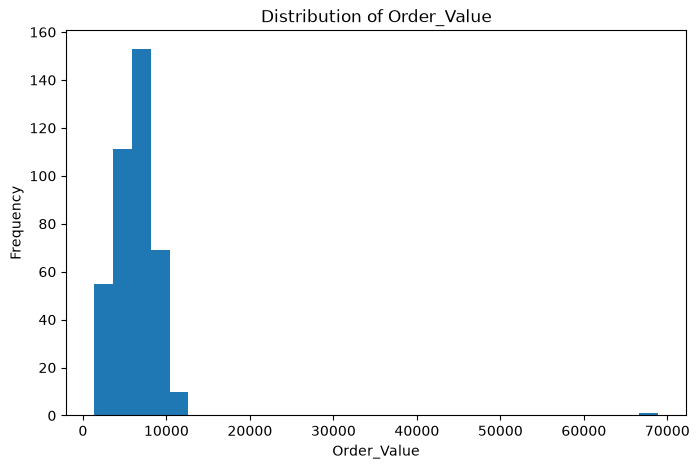

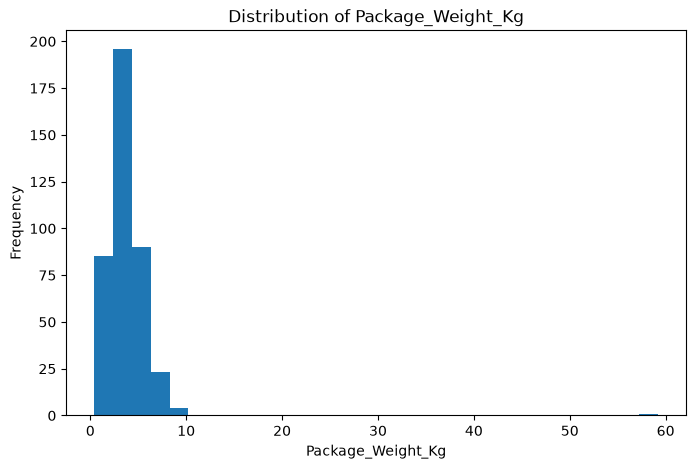

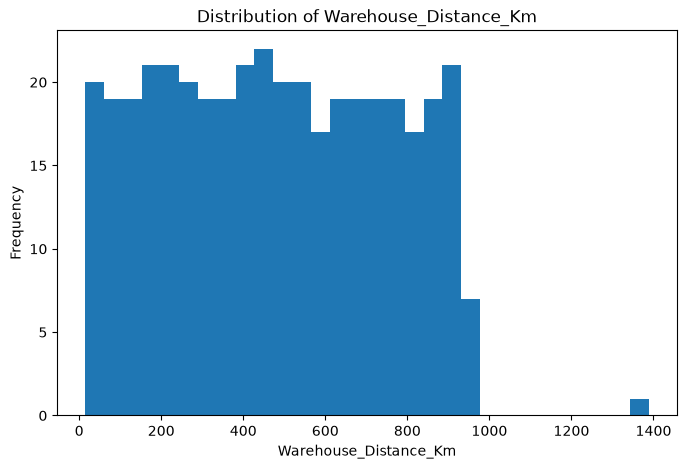

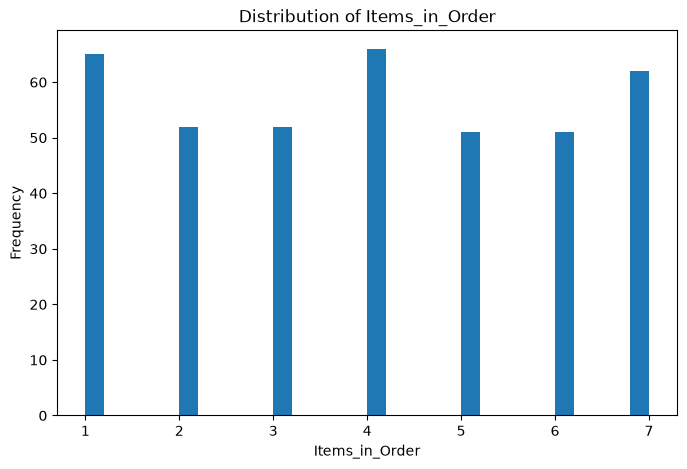

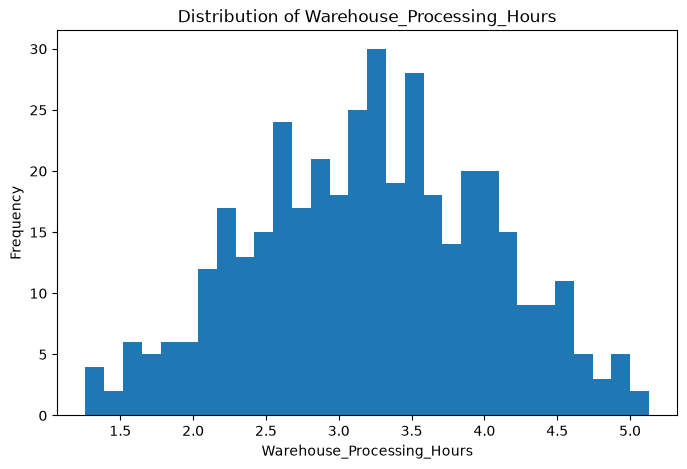

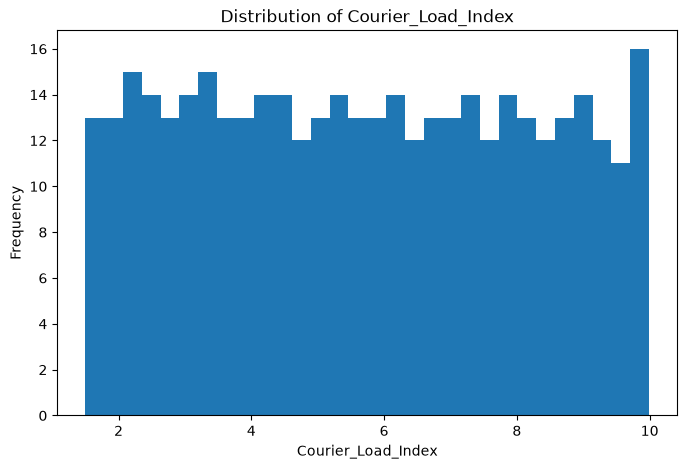

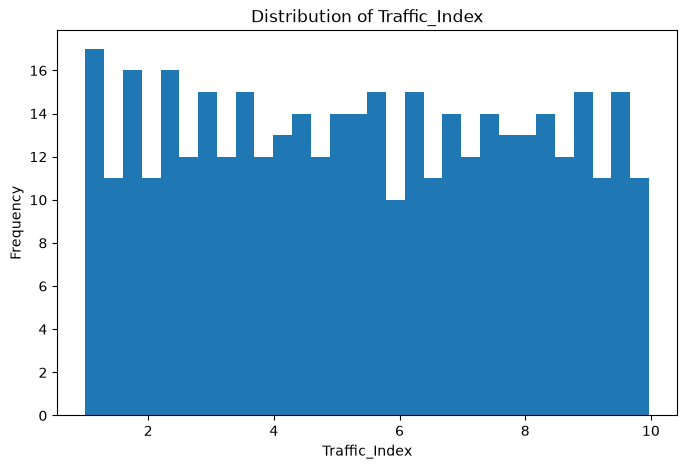

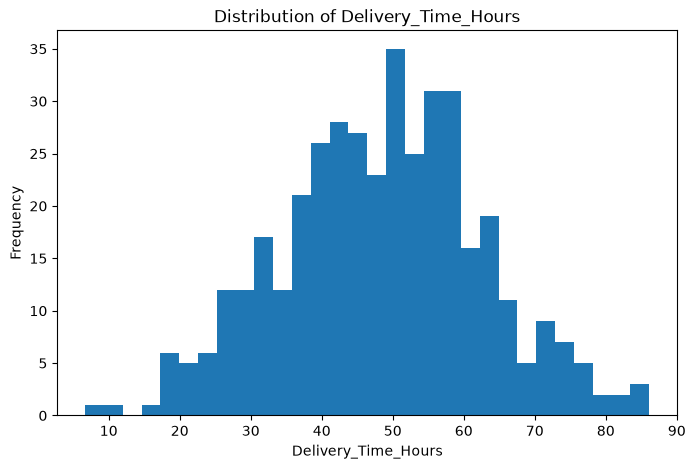

In [50]:
# Loop through every numerical variable
# A separate histogram will be created for each variable

for column in numerical_columns:

    # Create a new figure for the current variable
    plt.figure(figsize=(8, 5))

    # Plot the histogram
    # bins=30 divides the observations into 30 intervals
    plt.hist(df_analysis[column].dropna(), bins=30)

    # Add a descriptive title
    plt.title(f"Distribution of {column}")

    # Label the horizontal axis with the variable name
    plt.xlabel(column)

    # Label the vertical axis with frequency
    plt.ylabel("Frequency")

    # Display the graph
    plt.show()

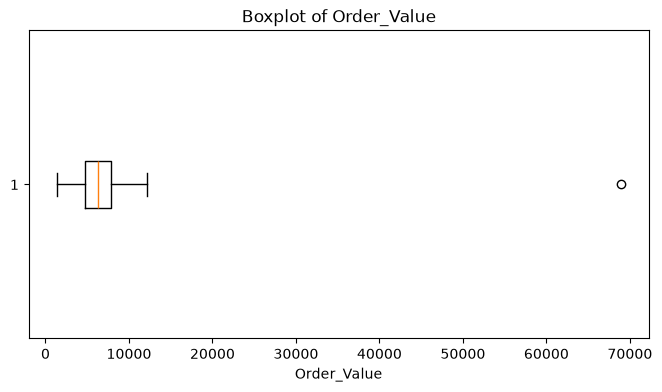

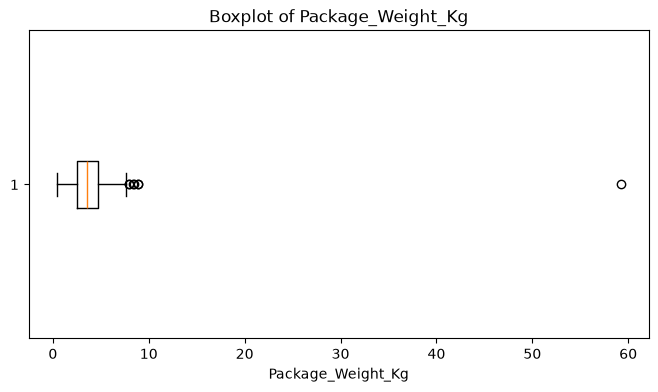

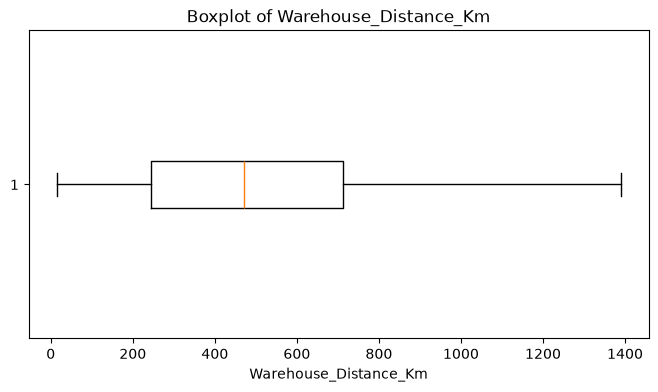

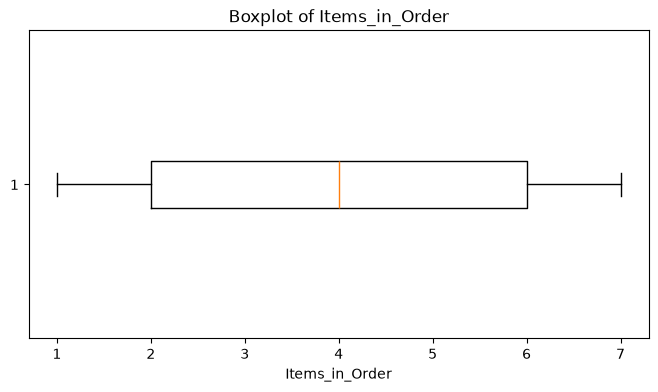

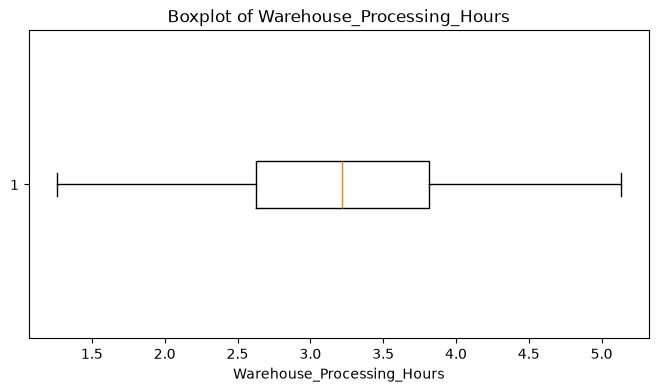

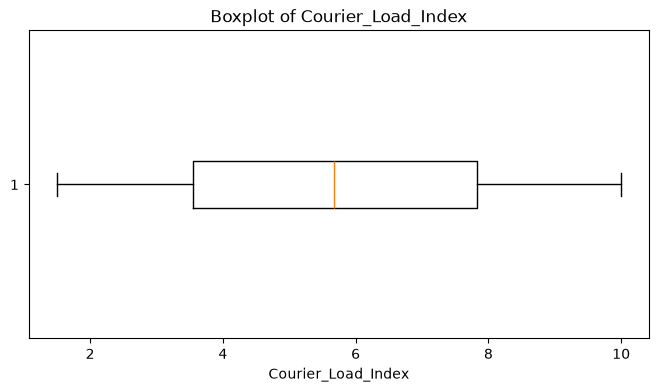

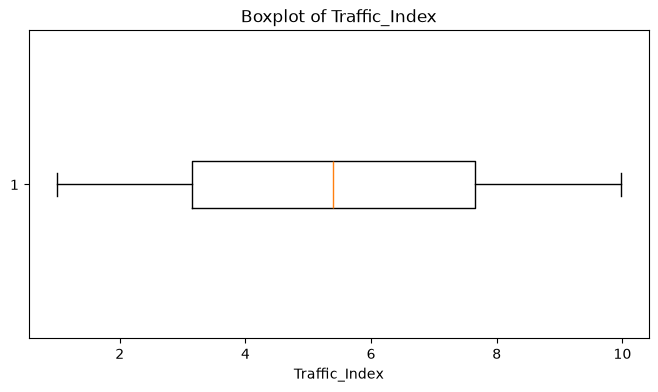

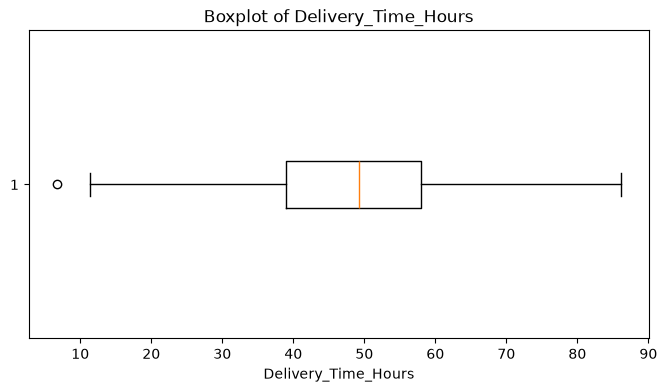

In [51]:
# Loop through each numerical variable
# A separate boxplot will be produced for every variable

for column in numerical_columns:

    # Create a new figure
    plt.figure(figsize=(8, 4))

    # Create a horizontal boxplot for the variable
    plt.boxplot(
        df_analysis[column].dropna(),
        vert=False
    )

    # Add a descriptive title
    plt.title(f"Boxplot of {column}")

    # Label the horizontal axis
    plt.xlabel(column)

    # Display the plot
    plt.show()

In [52]:
# Create an empty list where the outlier summary for
# each numerical variable will be stored
outlier_summary = []


# Loop through each numerical variable
for column in numerical_columns:

    # Calculate the first quartile (25th percentile)
    Q1 = df_analysis[column].quantile(0.25)

    # Calculate the third quartile (75th percentile)
    Q3 = df_analysis[column].quantile(0.75)

    # Calculate the Interquartile Range
    IQR = Q3 - Q1

    # Calculate the lower IQR boundary
    lower_bound = Q1 - (1.5 * IQR)

    # Calculate the upper IQR boundary
    upper_bound = Q3 + (1.5 * IQR)

    # Identify observations outside the IQR boundaries
    outliers = df_analysis[
        (df_analysis[column] < lower_bound) |
        (df_analysis[column] > upper_bound)
    ]

    # Store the results for this variable
    outlier_summary.append({
        "Variable": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Number_of_Potential_Outliers": len(outliers)
    })


# Convert the stored results into a DataFrame
outlier_summary_df = pd.DataFrame(outlier_summary)

# Display the IQR outlier summary
outlier_summary_df

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Number_of_Potential_Outliers
0,Order_Value,4701.000,7821.000,3120.000,21.0000,12501.0000,1
1,Package_Weight_Kg,2.505,4.660,2.155,-0.7275,7.8925,7
2,Warehouse_Distance_Km,245.450,711.600,466.150,-453.7750,1410.8250,0
3,Items_in_Order,2.000,6.000,4.000,-4.0000,12.0000,0
4,Warehouse_Processing_Hours,2.625,3.815,1.190,0.8400,5.6000,0
5,Courier_Load_Index,3.555,7.825,4.270,-2.8500,14.2300,0
6,Traffic_Index,3.145,7.660,4.515,-3.6275,14.4325,0
7,Delivery_Time_Hours,38.955,58.030,19.075,10.3425,86.6425,1


In [53]:
# Loop through every numerical variable
# and display the observations flagged by the IQR method

for column in numerical_columns:

    # Calculate Q1
    Q1 = df_analysis[column].quantile(0.25)

    # Calculate Q3
    Q3 = df_analysis[column].quantile(0.75)

    # Calculate the IQR
    IQR = Q3 - Q1

    # Calculate the lower acceptable boundary
    lower_bound = Q1 - (1.5 * IQR)

    # Calculate the upper acceptable boundary
    upper_bound = Q3 + (1.5 * IQR)

    # Select observations outside the calculated boundaries
    potential_outliers = df_analysis[
        (df_analysis[column] < lower_bound) |
        (df_analysis[column] > upper_bound)
    ]

    # Print the variable being analysed
    print("\nVariable:", column)

    # Print the number of observations flagged
    print("Number of potential outliers:", len(potential_outliers))

    # Display only Order_ID and the variable being investigated
    display(
        potential_outliers[
            ["Order_ID", column]
        ]
    )


Variable: Order_Value
Number of potential outliers: 1


,Order_ID,Order_Value
329,ORD100330,68880.0



Variable: Package_Weight_Kg
Number of potential outliers: 7


,Order_ID,Package_Weight_Kg
31,ORD100032,7.90
57,ORD100058,59.20
125,ORD100126,8.45
217,ORD100218,8.31
241,ORD100242,7.97
311,ORD100312,8.86
391,ORD100393,8.91



Variable: Warehouse_Distance_Km
Number of potential outliers: 0


...

,Order_ID,Courier_Load_Index



Variable: Traffic_Index
Number of potential outliers: 0


,Order_ID,Traffic_Index



Variable: Delivery_Time_Hours
Number of potential outliers: 1


,Order_ID,Delivery_Time_Hours
1,ORD100002,6.71


In [54]:
# Define the continuous numerical predictors
# These will be examined against Delivery_Time_Hours
# to determine whether their relationships appear reasonably linear

continuous_predictors = [
    "Order_Value",
    "Package_Weight_Kg",
    "Warehouse_Distance_Km",
    "Warehouse_Processing_Hours",
    "Courier_Load_Index",
    "Traffic_Index"
]

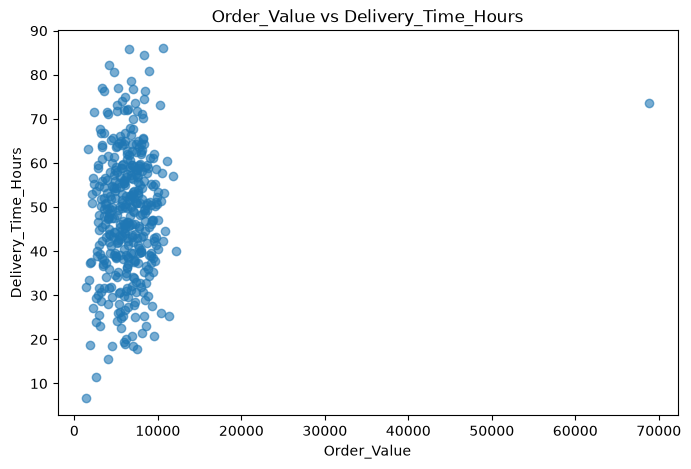

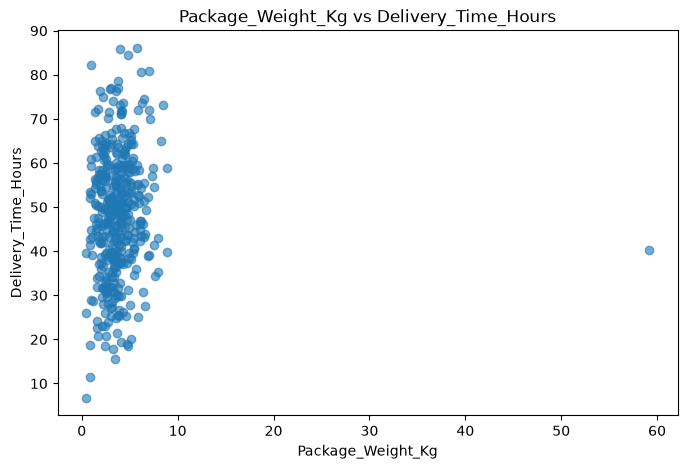

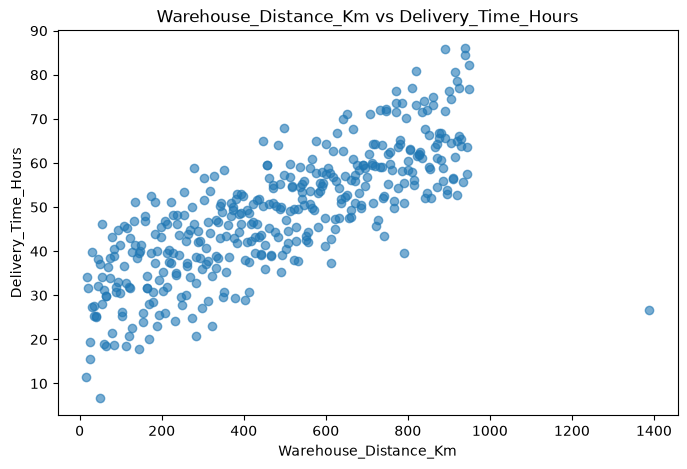

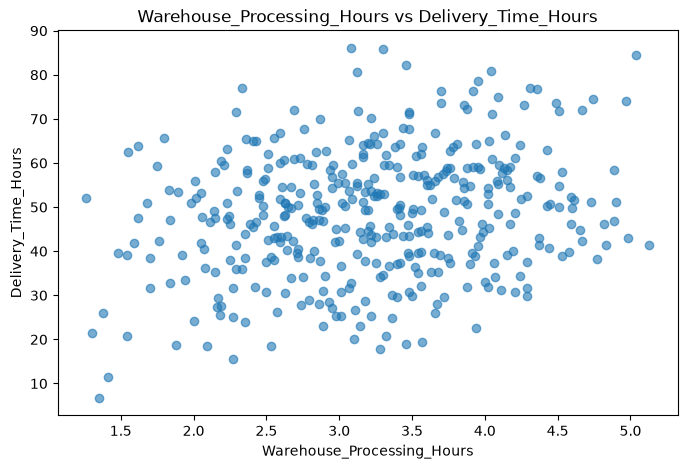

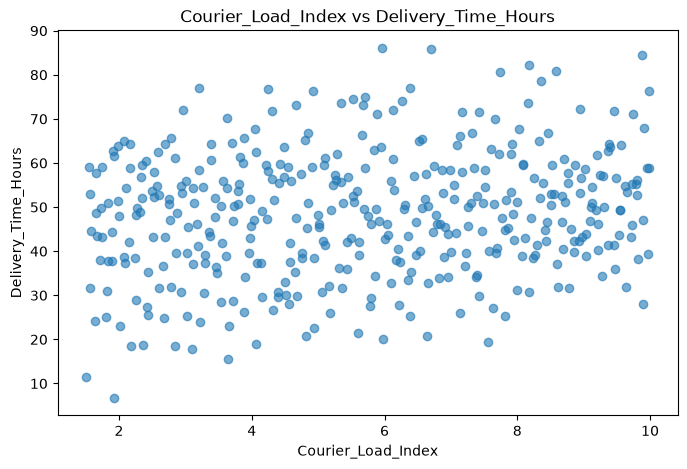

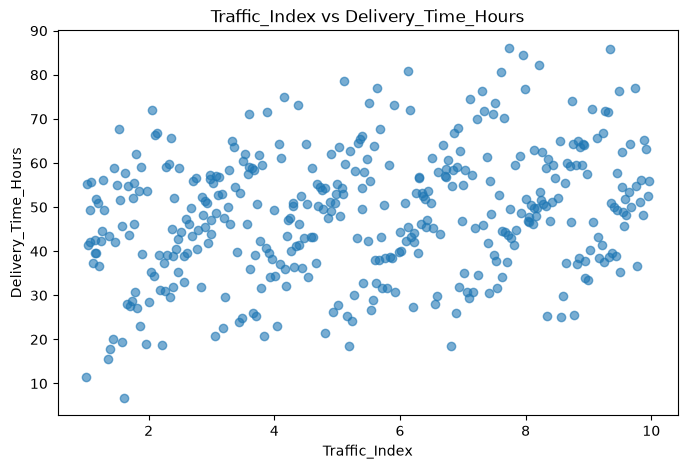

In [55]:
# Loop through each continuous predictor
# and examine its relationship with Delivery_Time_Hours

for column in continuous_predictors:

    # Create a new figure for the current predictor
    plt.figure(figsize=(8, 5))

    # Create a scatterplot
    # X-axis = predictor variable
    # Y-axis = target variable
    plt.scatter(
        df_analysis[column],
        df_analysis["Delivery_Time_Hours"],
        alpha=0.6
    )

    # Add a descriptive title
    plt.title(
        f"{column} vs Delivery_Time_Hours"
    )

    # Label the predictor axis
    plt.xlabel(column)

    # Label the target axis
    plt.ylabel("Delivery_Time_Hours")

    # Display the graph
    plt.show()

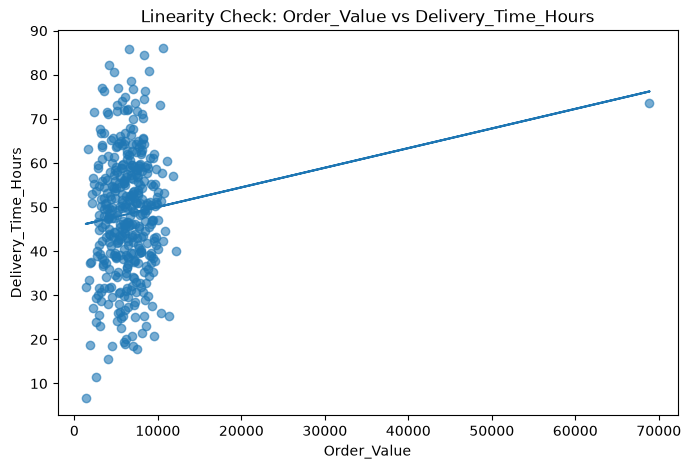

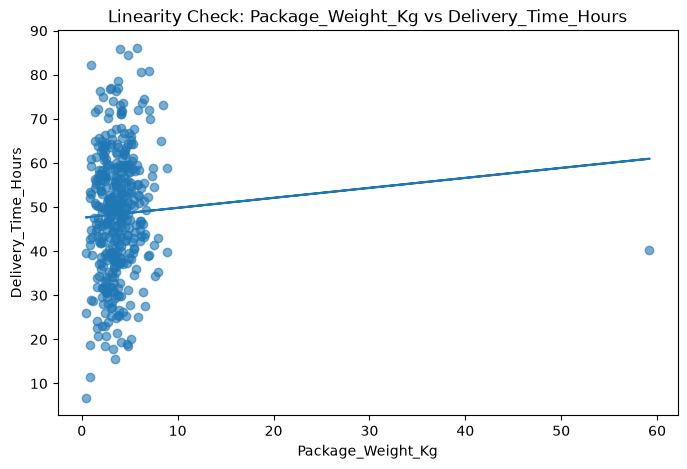

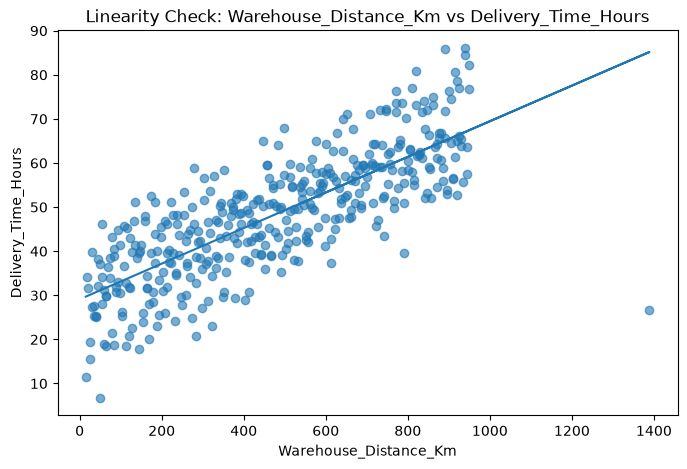

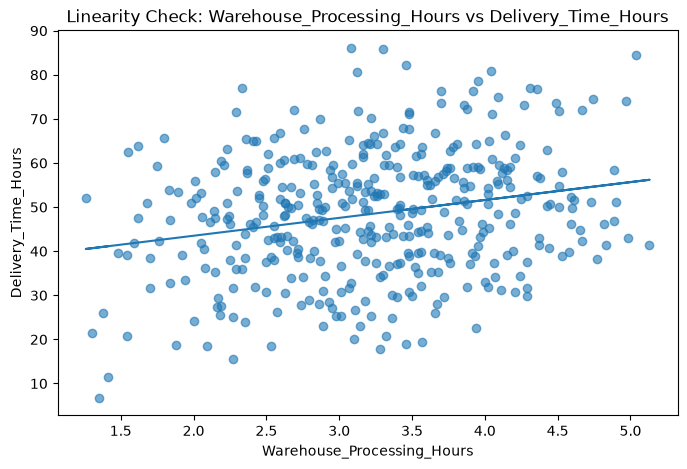

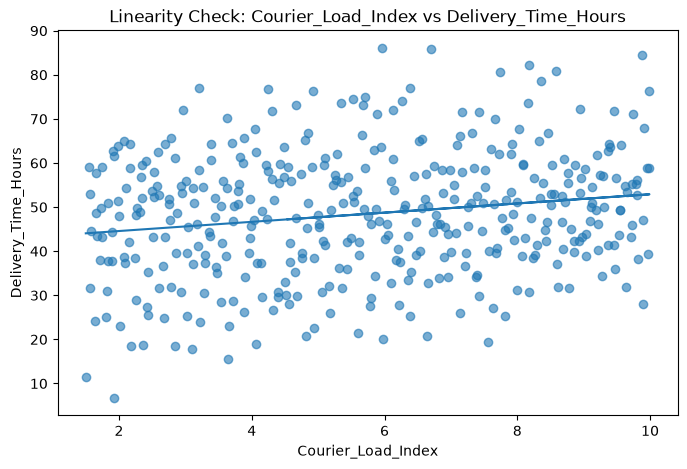

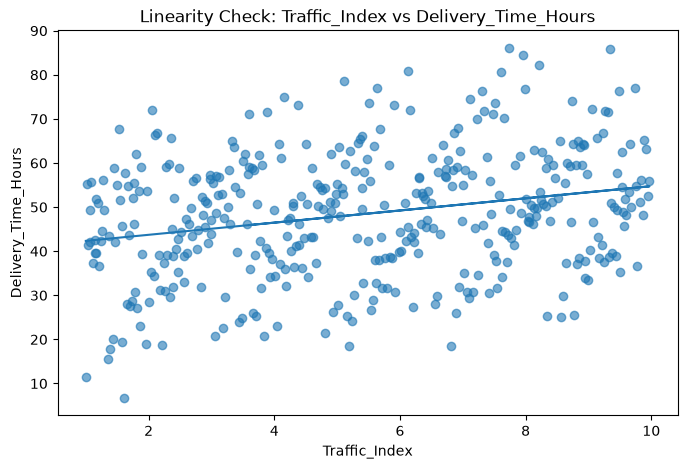

In [56]:
# Loop through each continuous predictor
# and plot both the observations and a fitted straight line

for column in continuous_predictors:

    # Create a new figure
    plt.figure(figsize=(8, 5))

    # Plot the actual observations
    plt.scatter(
        df_analysis[column],
        df_analysis["Delivery_Time_Hours"],
        alpha=0.6
    )

    # Calculate the slope and intercept of a simple fitted line
    slope, intercept = np.polyfit(
        df_analysis[column],
        df_analysis["Delivery_Time_Hours"],
        1
    )

    # Generate predicted Y values for the fitted line
    fitted_line = (
        slope * df_analysis[column]
        + intercept
    )

    # Plot the fitted regression line
    plt.plot(
        df_analysis[column],
        fitted_line
    )

    # Add a descriptive title
    plt.title(
        f"Linearity Check: {column} vs Delivery_Time_Hours"
    )

    # Label the X-axis
    plt.xlabel(column)

    # Label the Y-axis
    plt.ylabel("Delivery_Time_Hours")

    # Display the graph
    plt.show()

### Outlier Analysis - Initial Findings

Potential outliers were identified using boxplots and the 1.5 × IQR rule.

The IQR analysis identified:
- 1 potential outlier in Order_Value
- 7 potential outliers in Package_Weight_Kg
- 1 potential outlier in Delivery_Time_Hours
- No IQR outliers in Warehouse_Distance_Km, Items_in_Order,
  Warehouse_Processing_Hours, Courier_Load_Index, or Traffic_Index

These observations were not removed at this stage because an observation
being outside the IQR limits does not necessarily imply that it is erroneous.
Their influence on the linear regression model will subsequently be examined
using residual diagnostics and Cook's Distance.

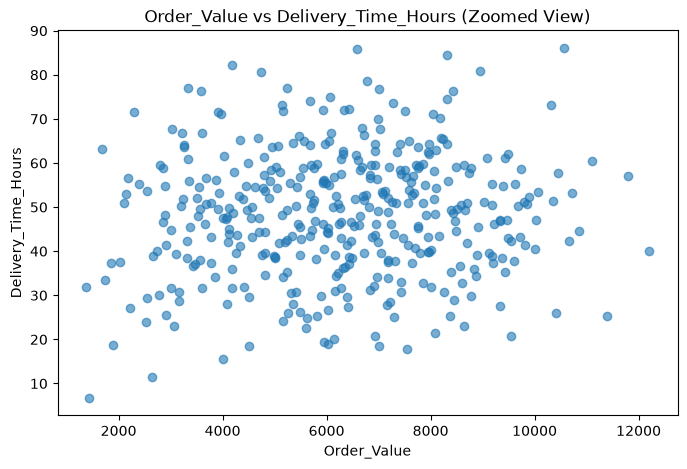

In [57]:
# Create a temporary subset only for visualising the normal range of Order_Value
# This does NOT modify df_analysis and does NOT remove the outlier from our model

order_value_visual = df_analysis[
    df_analysis["Order_Value"] <= 12501
]


# Create a scatterplot using only the normal IQR range for easier visual inspection
plt.figure(figsize=(8, 5))

# Plot Order_Value against Delivery_Time_Hours
plt.scatter(
    order_value_visual["Order_Value"],
    order_value_visual["Delivery_Time_Hours"],
    alpha=0.6
)

# Add a descriptive title
plt.title(
    "Order_Value vs Delivery_Time_Hours (Zoomed View)"
)

# Label the horizontal axis
plt.xlabel("Order_Value")

# Label the vertical axis
plt.ylabel("Delivery_Time_Hours")

# Display the graph
plt.show()

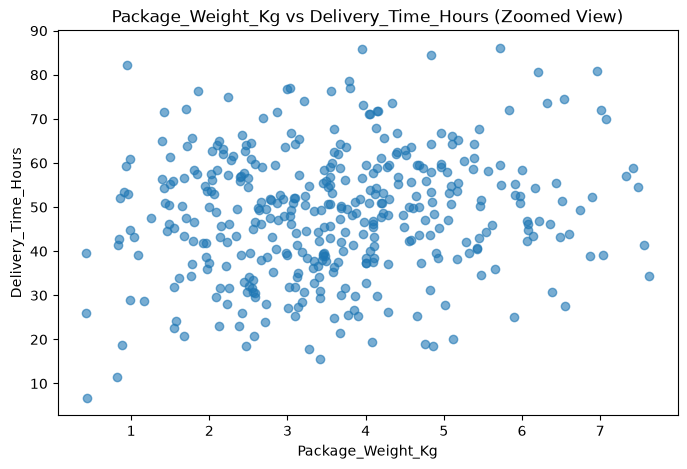

In [58]:
# Create a temporary subset for visual inspection of Package_Weight_Kg
# The IQR upper limit obtained from our analysis is 7.8925 kg
# This does NOT change or delete anything from df_analysis

weight_visual = df_analysis[
    df_analysis["Package_Weight_Kg"] <= 7.8925
]


# Create a scatterplot of the main package-weight range
plt.figure(figsize=(8, 5))

# Plot Package_Weight_Kg against the target variable
plt.scatter(
    weight_visual["Package_Weight_Kg"],
    weight_visual["Delivery_Time_Hours"],
    alpha=0.6
)

# Add a descriptive title
plt.title(
    "Package_Weight_Kg vs Delivery_Time_Hours (Zoomed View)"
)

# Label the X-axis
plt.xlabel("Package_Weight_Kg")

# Label the Y-axis
plt.ylabel("Delivery_Time_Hours")

# Display the graph
plt.show()

In [59]:
# Create a list containing only the numerical predictor variables
# Delivery_Time_Hours is excluded because multicollinearity concerns
# relationships BETWEEN predictors rather than between X and Y

numerical_predictors = [
    "Order_Value",
    "Package_Weight_Kg",
    "Warehouse_Distance_Km",
    "Items_in_Order",
    "Warehouse_Processing_Hours",
    "Courier_Load_Index",
    "Traffic_Index"
]


# Calculate the Pearson correlation matrix between numerical predictors
correlation_matrix = df_analysis[
    numerical_predictors
].corr()


# Display the numerical correlation matrix
correlation_matrix

,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index
Order_Value,1.000000,0.120838,0.051600,0.324521,0.159364,0.053619,-0.013230
Package_Weight_Kg,0.120838,1.000000,-0.034210,0.281259,0.124777,0.082205,0.063967
Warehouse_Distance_Km,0.051600,-0.034210,1.000000,-0.051612,0.001831,-0.019787,0.018430
Items_in_Order,0.324521,0.281259,-0.051612,1.000000,0.548992,0.022683,-0.000784
Warehouse_Processing_Hours,0.159364,0.124777,0.001831,0.548992,1.000000,0.201759,-0.039253
Courier_Load_Index,0.053619,0.082205,-0.019787,0.022683,0.201759,1.000000,0.001893
Traffic_Index,-0.013230,0.063967,0.018430,-0.000784,-0.039253,0.001893,1.000000


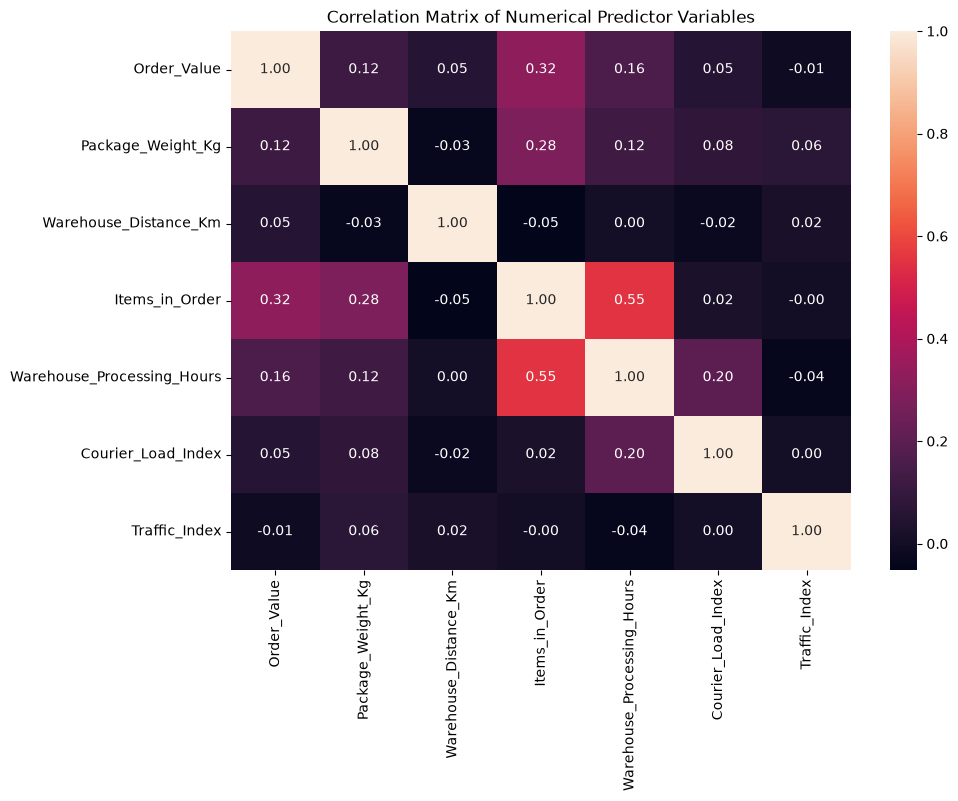

In [60]:
# Create a figure large enough to clearly display the correlation matrix
plt.figure(figsize=(10, 7))

# Create a heatmap of correlations between numerical predictors
# annot=True displays the correlation coefficient inside each cell
# fmt=".2f" displays each coefficient to two decimal places
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

# Add a title explaining what the graph represents
plt.title(
    "Correlation Matrix of Numerical Predictor Variables"
)

# Display the heatmap
plt.show()

| Absolute correlation | Meaning                             |
| -------------------: | ----------------------------------- |
|            0.00–0.30 | Weak                                |
|            0.30–0.50 | Moderate                            |
|            0.50–0.70 | Relatively strong                   |
|          > 0.70–0.80 | Potential multicollinearity concern |
|      Very close to 1 | Serious redundancy                  |


In [61]:
# Create a predictor dataset by removing:
# Order_ID because it is only an identifier
# Delivery_Time_Hours because it is our target variable

X_vif = df_analysis.drop(
    columns=[
        "Order_ID",
        "Delivery_Time_Hours"
    ]
)


# Convert categorical predictors into dummy/indicator variables
# drop_first=True removes one category from each categorical variable
# and prevents perfect dummy-variable multicollinearity

X_vif = pd.get_dummies(
    X_vif,
    columns=[
        "Product_Category",
        "Shipping_Mode"
    ],
    drop_first=True,
    dtype=float
)


# Display the first five rows of the encoded predictor dataset
X_vif.head()

,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Product_Category_Books,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Home & Kitchen,Shipping_Mode_Same-Day,Shipping_Mode_Standard
0,2650.0,0.82,15.0,1.0,1.41,1.50,1.00,0.0,1.0,0.0,0.0,0.0,1.0
1,1433.0,0.44,49.7,1.0,1.35,1.93,1.61,0.0,0.0,0.0,0.0,1.0,0.0
2,1886.0,0.88,84.5,1.0,1.88,2.36,2.22,0.0,0.0,1.0,0.0,0.0,0.0
3,1369.0,1.55,119.2,1.0,2.42,2.79,2.83,1.0,0.0,0.0,0.0,0.0,1.0
4,2532.0,2.71,153.9,1.0,2.35,3.22,3.44,0.0,0.0,0.0,1.0,1.0,0.0


In [62]:
# Import variance_inflation_factor
# This function calculates VIF for each predictor
# VIF measures how strongly a predictor can be explained
# by the other predictors in the model

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [63]:
# Add a constant/intercept column because our regression model
# will also contain an intercept

X_vif_constant = sm.add_constant(X_vif)


# Create an empty DataFrame to store VIF results
vif_table = pd.DataFrame()


# Store the name of each predictor
vif_table["Variable"] = X_vif_constant.columns


# Calculate VIF for every predictor
# range() goes through each column position one-by-one

vif_table["VIF"] = [
    variance_inflation_factor(
        X_vif_constant.values,
        i
    )
    for i in range(X_vif_constant.shape[1])
]


# Display the VIF results
vif_table

,Variable,VIF
0,const,33.931909
1,Order_Value,1.162282
2,Package_Weight_Kg,1.219387
3,Warehouse_Distance_Km,1.014982
4,Items_in_Order,1.757562
5,Warehouse_Processing_Hours,1.617833
6,Courier_Load_Index,1.074096
7,Traffic_Index,1.008898
8,Product_Category_Books,1.651737
9,Product_Category_Electronics,1.678994


VIF ≈ 1       → practically no multicollinearity
VIF 1–5       → generally acceptable
VIF 5–10      → concerning
VIF > 10      → serious multicollinearity

In [64]:
# Create the target/dependent variable y
# Delivery_Time_Hours is the numerical outcome that our regression model will predict
y = df_analysis["Delivery_Time_Hours"]


# Create the predictor dataset X
# Order_ID is removed because it is only an identifier
# Delivery_Time_Hours is removed because it is the target variable
X = df_analysis.drop(
    columns=[
        "Order_ID",
        "Delivery_Time_Hours"
    ]
)


# Display the first 5 rows of the predictor dataset
# This helps confirm that only the intended predictor variables are present
X.head()

,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index
0,Electronics,Standard,2650.0,0.82,15.0,1.0,1.41,1.50,1.00
1,Beauty,Same-Day,1433.0,0.44,49.7,1.0,1.35,1.93,1.61
2,Fashion,Express,1886.0,0.88,84.5,1.0,1.88,2.36,2.22
3,Books,Standard,1369.0,1.55,119.2,1.0,2.42,2.79,2.83
4,Home & Kitchen,Same-Day,2532.0,2.71,153.9,1.0,2.35,3.22,3.44


In [65]:
# Convert categorical predictor variables into dummy variables
# Each category becomes a numerical 0/1 indicator variable

# drop_first=True removes one category from each categorical variable
# This avoids perfect multicollinearity caused by the dummy-variable trap

# dtype=float ensures that the newly created dummy columns are numerical
X_encoded = pd.get_dummies(
    X,
    columns=[
        "Product_Category",
        "Shipping_Mode"
    ],
    drop_first=True,
    dtype=float
)


# Display the first 5 rows after categorical encoding
X_encoded.head()

,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Product_Category_Books,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Home & Kitchen,Shipping_Mode_Same-Day,Shipping_Mode_Standard
0,2650.0,0.82,15.0,1.0,1.41,1.50,1.00,0.0,1.0,0.0,0.0,0.0,1.0
1,1433.0,0.44,49.7,1.0,1.35,1.93,1.61,0.0,0.0,0.0,0.0,1.0,0.0
2,1886.0,0.88,84.5,1.0,1.88,2.36,2.22,0.0,0.0,1.0,0.0,0.0,0.0
3,1369.0,1.55,119.2,1.0,2.42,2.79,2.83,1.0,0.0,0.0,0.0,0.0,1.0
4,2532.0,2.71,153.9,1.0,2.35,3.22,3.44,0.0,0.0,0.0,1.0,1.0,0.0


In [66]:
# Display all predictor columns that will be used in the regression model
# This also shows which dummy variables were created for categorical predictors
X_encoded.columns.tolist()

['Order_Value',
 'Package_Weight_Kg',
 'Warehouse_Distance_Km',
 'Items_in_Order',
 'Warehouse_Processing_Hours',
 'Courier_Load_Index',
 'Traffic_Index',
 'Product_Category_Books',
 'Product_Category_Electronics',
 'Product_Category_Fashion',
 'Product_Category_Home & Kitchen',
 'Shipping_Mode_Same-Day',
 'Shipping_Mode_Standard']

In [67]:
# Add a constant column to the predictor dataset
# This allows statsmodels to estimate the regression intercept (beta_0)

X_encoded_constant = sm.add_constant(X_encoded)


# Display the first 5 rows to confirm that the constant was added
X_encoded_constant.head()

,const,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Product_Category_Books,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Home & Kitchen,Shipping_Mode_Same-Day,Shipping_Mode_Standard
0,1.0,2650.0,0.82,15.0,1.0,1.41,1.50,1.00,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,1433.0,0.44,49.7,1.0,1.35,1.93,1.61,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,1886.0,0.88,84.5,1.0,1.88,2.36,2.22,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,1369.0,1.55,119.2,1.0,2.42,2.79,2.83,1.0,0.0,0.0,0.0,0.0,1.0
4,1.0,2532.0,2.71,153.9,1.0,2.35,3.22,3.44,0.0,0.0,0.0,1.0,1.0,0.0


In [68]:
# Build an Ordinary Least Squares (OLS) multiple linear regression model
# y contains the target variable
# X_encoded_constant contains all numerical and encoded predictors

initial_model = sm.OLS(
    y,
    X_encoded_constant
)


# Fit the regression model to the available observations
# This estimates the intercept and regression coefficients
initial_results = initial_model.fit()

In [69]:
# Display the complete statistical summary of the multiple linear regression model
# This includes:
# - R-squared
# - Adjusted R-squared
# - Regression coefficients
# - Standard errors
# - t-statistics
# - p-values
# - F-statistic
# - Confidence intervals
# - Durbin-Watson statistic
# and other regression diagnostics

print(initial_results.summary())

                             OLS Regression Results                            
Dep. Variable:     Delivery_Time_Hours   R-squared:                       0.895
Model:                             OLS   Adj. R-squared:                  0.892
Method:                  Least Squares   F-statistic:                     253.7
Date:                 Wed, 09 Sep 2026   Prob (F-statistic):          1.21e-179
Time:                         15:28:15   Log-Likelihood:                -1172.3
No. Observations:                  399   AIC:                             2373.
Df Residuals:                      385   BIC:                             2428.
Df Model:                           13                                         
Covariance Type:             nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------


In [70]:
# Create a DataFrame containing the regression coefficients
# Each coefficient represents the estimated change in Delivery_Time_Hours
# associated with a one-unit increase in that predictor,
# while holding all other predictors constant

coefficient_table = pd.DataFrame({
    
    # Store the predictor names
    "Variable": initial_results.params.index,
    
    # Store the estimated regression coefficients
    "Coefficient": initial_results.params.values,
    
    # Store the p-value associated with each coefficient
    # P-values help assess whether the predictor has a statistically significant relationship
    # with the target after controlling for the other variables
    "P_Value": initial_results.pvalues.values
})


# Display the regression coefficient table
coefficient_table

,Variable,Coefficient,P_Value
0,const,7.504804,5.809595e-08
1,Order_Value,0.000012,8.516783e-01
2,Package_Weight_Kg,0.013287,8.685381e-01
3,Warehouse_Distance_Km,0.040574,7.009503e-162
4,Items_in_Order,0.798950,2.210097e-07
5,Warehouse_Processing_Hours,1.132466,2.043464e-03
6,Courier_Load_Index,1.070844,2.253008e-24
7,Traffic_Index,1.349993,1.943517e-40
8,Product_Category_Books,0.184798,8.066487e-01
9,Product_Category_Electronics,0.076524,9.180510e-01


In [71]:
# Add a column identifying predictors that are statistically significant
# A conventional significance level of 0.05 is being used

coefficient_table["Significant_at_5%"] = (
    coefficient_table["P_Value"] < 0.05
)


# Display the updated coefficient table
coefficient_table

,Variable,Coefficient,P_Value,Significant_at_5%
0,const,7.504804,5.809595e-08,True
1,Order_Value,0.000012,8.516783e-01,False
2,Package_Weight_Kg,0.013287,8.685381e-01,False
3,Warehouse_Distance_Km,0.040574,7.009503e-162,True
4,Items_in_Order,0.798950,2.210097e-07,True
5,Warehouse_Processing_Hours,1.132466,2.043464e-03,True
6,Courier_Load_Index,1.070844,2.253008e-24,True
7,Traffic_Index,1.349993,1.943517e-40,True
8,Product_Category_Books,0.184798,8.066487e-01,False
9,Product_Category_Electronics,0.076524,9.180510e-01,False


True  = statistically significant at the 5% level
False = not statistically significant at the 5% level

In [72]:
# Generate fitted/predicted Delivery_Time_Hours values
# using the initial multiple linear regression model

predicted_delivery_time = initial_results.predict(
    X_encoded_constant
)


# Display the first 5 predicted values
predicted_delivery_time.head()

0    21.586201
1    10.457306
2    19.019073
3    30.911844
4    21.609767
dtype: float64

In [73]:
# Calculate regression residuals
# Residuals represent the difference between actual and predicted delivery times

residuals = y - predicted_delivery_time


# Display the first 5 residual values
residuals.head()

0   -10.196201
1    -3.747306
2    -0.389073
3     0.898156
4     2.400233
dtype: float64

In [74]:
# Create a separate DataFrame for regression diagnostics
# This prevents us from modifying df_analysis unnecessarily

regression_diagnostics = df_analysis.copy()


# Add the model's predicted delivery time to the diagnostic dataset
regression_diagnostics["Predicted_Delivery_Time"] = predicted_delivery_time.values


# Add the residual for every observation
regression_diagnostics["Residual"] = residuals.values


# Display the first 5 observations
regression_diagnostics.head()

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours,Predicted_Delivery_Time,Residual
0,ORD100001,Electronics,Standard,2650.0,0.82,15.0,1.0,1.41,1.50,1.00,11.39,21.586201,-10.196201
1,ORD100002,Beauty,Same-Day,1433.0,0.44,49.7,1.0,1.35,1.93,1.61,6.71,10.457306,-3.747306
2,ORD100003,Fashion,Express,1886.0,0.88,84.5,1.0,1.88,2.36,2.22,18.63,19.019073,-0.389073
3,ORD100004,Books,Standard,1369.0,1.55,119.2,1.0,2.42,2.79,2.83,31.81,30.911844,0.898156
4,ORD100005,Home & Kitchen,Same-Day,2532.0,2.71,153.9,1.0,2.35,3.22,3.44,24.01,21.609767,2.400233


In [75]:
# Extract R-squared from the fitted regression model
# R-squared represents the proportion of variation in Delivery_Time_Hours
# explained by the predictors in the model
r_squared = initial_results.rsquared


# Extract Adjusted R-squared
# Adjusted R-squared accounts for the number of predictors in the model
# and is therefore more appropriate when multiple predictors are included
adjusted_r_squared = initial_results.rsquared_adj


# Display both model-fit measures
print("R-squared:", round(r_squared, 4))
print("Adjusted R-squared:", round(adjusted_r_squared, 4))

R-squared: 0.8955
Adjusted R-squared: 0.8919


In [76]:
# Import regression evaluation metrics from scikit-learn

# mean_absolute_error calculates the average absolute prediction error
# mean_squared_error calculates the average squared prediction error
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [77]:
# Calculate Mean Absolute Error (MAE)
# MAE tells us the average absolute difference between
# actual and predicted delivery times
mae = mean_absolute_error(
    y,
    predicted_delivery_time
)


# Calculate Mean Squared Error (MSE)
# MSE gives greater penalty to larger prediction errors
mse = mean_squared_error(
    y,
    predicted_delivery_time
)


# Calculate Root Mean Squared Error (RMSE)
# Taking the square root converts MSE back into the unit of hours
rmse = np.sqrt(mse)


# Display the evaluation metrics
print("MAE:", round(mae, 4))
print("MSE:", round(mse, 4))
print("RMSE:", round(rmse, 4))

MAE: 3.0501
MSE: 20.8697
RMSE: 4.5683


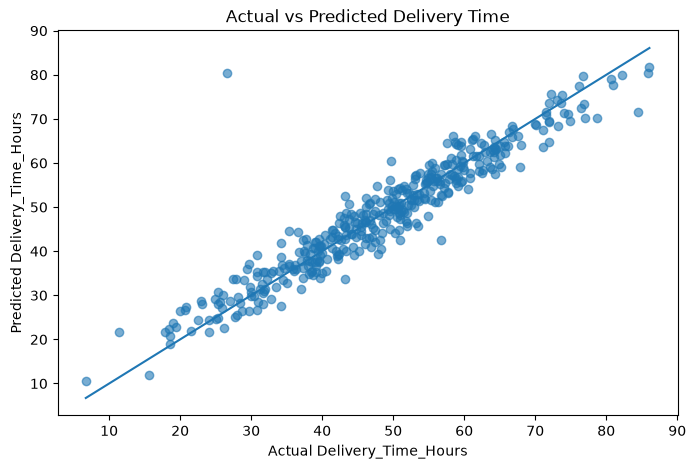

In [78]:
# Create a scatterplot comparing actual delivery times
# against the delivery times predicted by the model

plt.figure(figsize=(8, 5))


# Plot actual values on the X-axis
# and predicted values on the Y-axis
plt.scatter(
    y,
    predicted_delivery_time,
    alpha=0.6
)


# Add the ideal 45-degree prediction line
# Points close to this line represent more accurate predictions

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()]
)


# Add a descriptive title
plt.title(
    "Actual vs Predicted Delivery Time"
)


# Label the horizontal axis
plt.xlabel(
    "Actual Delivery_Time_Hours"
)


# Label the vertical axis
plt.ylabel(
    "Predicted Delivery_Time_Hours"
)


# Display the graph
plt.show()

In [79]:
# Import the Durbin-Watson test
# This checks whether regression residuals are correlated with one another
from statsmodels.stats.stattools import durbin_watson


# Calculate the Durbin-Watson statistic using the model residuals
dw_statistic = durbin_watson(residuals)


# Display the result
print("Durbin-Watson Statistic:", round(dw_statistic, 4))

Durbin-Watson Statistic: 2.0226


Around 2  → residuals are approximately independent
Below 2   → possible positive autocorrelation
Above 2   → possible negative autocorrelation

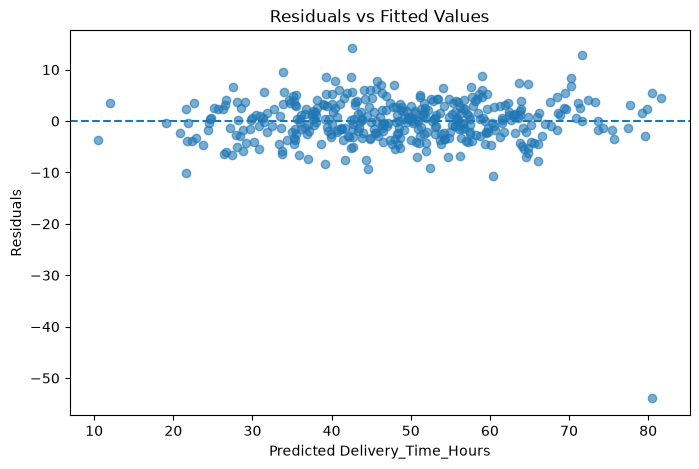

In [80]:
# Create a figure for the residual-versus-fitted plot
plt.figure(figsize=(8, 5))


# Plot predicted delivery times on the X-axis
# Plot residuals on the Y-axis
plt.scatter(
    predicted_delivery_time,
    residuals,
    alpha=0.6
)


# Add a horizontal reference line at residual = 0
# Ideally, residuals should be randomly scattered around this line
plt.axhline(
    y=0,
    linestyle="--"
)


# Add a descriptive title
plt.title("Residuals vs Fitted Values")


# Label the horizontal axis
plt.xlabel("Predicted Delivery_Time_Hours")


# Label the vertical axis
plt.ylabel("Residuals")


# Display the graph
plt.show()

In [81]:
# Display only the most relevant information for the observation
# with the largest negative prediction error

regression_diagnostics.loc[
    regression_diagnostics["Residual"].idxmin(),
    [
        "Order_ID",
        "Order_Value",
        "Package_Weight_Kg",
        "Warehouse_Distance_Km",
        "Items_in_Order",
        "Warehouse_Processing_Hours",
        "Courier_Load_Index",
        "Traffic_Index",
        "Delivery_Time_Hours",
        "Predicted_Delivery_Time",
        "Residual"
    ]
]

Order_ID                      ORD100184
Order_Value                      6029.0
Package_Weight_Kg                  3.85
Warehouse_Distance_Km            1389.0
Items_in_Order                      1.0
Warehouse_Processing_Hours         3.11
Courier_Load_Index                 4.32
Traffic_Index                      5.54
Delivery_Time_Hours               26.62
Predicted_Delivery_Time       80.490499
Residual                     -53.870499
Name: 183, dtype: object

### Residuals vs Fitted Values

The residuals are generally distributed around the zero line without a clear
systematic curved pattern, suggesting that the linearity assumption is
reasonably satisfied.

The spread of the majority of residuals also appears relatively stable across
fitted values. However, one observation has a substantially larger negative
residual than the rest of the dataset.

Therefore, no observation is removed at this stage. The extreme residual will
be investigated further using standardized residuals, leverage and Cook's
Distance before making any corrective decision.

In [82]:
# Import the Breusch-Pagan test
# This formally checks whether the variance of the regression residuals
# remains approximately constant across fitted values

from statsmodels.stats.diagnostic import het_breuschpagan


# Perform the Breusch-Pagan test
# residuals contains the errors from our fitted regression model
# X_encoded_constant contains all predictors including the intercept

bp_test = het_breuschpagan(
    residuals,
    X_encoded_constant
)


# Give names to the four statistics returned by the test
bp_labels = [
    "LM Statistic",
    "LM Test p-value",
    "F Statistic",
    "F Test p-value"
]


# Combine the statistic names with their calculated values
bp_results = dict(zip(bp_labels, bp_test))


# Display the Breusch-Pagan results clearly
for name, value in bp_results.items():
    print(name, ":", round(value, 4))

LM Statistic : 21.1232
LM Test p-value : 0.0705
F Statistic : 1.6555
F Test p-value : 0.0683


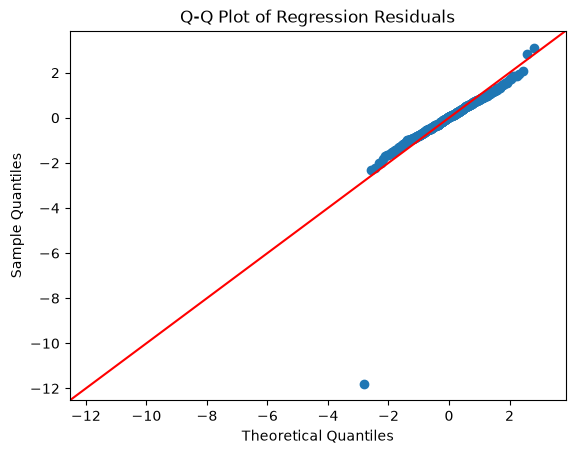

In [83]:
# Create a Q-Q plot of the regression residuals
# This compares the actual residual distribution with
# what would be expected under a normal distribution

sm.qqplot(
    residuals,
    line="45",
    fit=True
)

# Add a descriptive title
plt.title("Q-Q Plot of Regression Residuals")

# Display the graph
plt.show()

In [84]:
# Import the Jarque-Bera test
# This provides a formal statistical test of whether residuals follow
# an approximately normal distribution
from statsmodels.stats.stattools import jarque_bera


# Perform the Jarque-Bera test on the regression residuals
jb_statistic, jb_pvalue, skewness, kurtosis = jarque_bera(residuals)


# Display the test results
print("Jarque-Bera Statistic:", round(jb_statistic, 4))
print("Jarque-Bera p-value:", round(jb_pvalue, 4))
print("Residual Skewness:", round(skewness, 4))
print("Residual Kurtosis:", round(kurtosis, 4))

Jarque-Bera Statistic: 37671.2612
Jarque-Bera p-value: 0.0
Residual Skewness: -3.9913
Residual Kurtosis: 49.9278


p-value > 0.05
→ no strong evidence against residual normality

p-value < 0.05
→ residuals significantly deviate from normality

In [86]:
# Obtain regression influence statistics from the fitted OLS model
# This object is required to calculate standardized residuals,
# leverage values and Cook's Distance

influence = initial_results.get_influence()

In [87]:
# Calculate standardized residuals
# These express each residual relative to its estimated standard deviation

standardized_residuals = influence.resid_studentized_internal


# Add standardized residuals to our regression diagnostic dataset
regression_diagnostics["Standardized_Residual"] = standardized_residuals

In [88]:
# Create a temporary column containing the absolute standardized residual
# Absolute values allow us to rank both large positive and negative residuals

regression_diagnostics["Absolute_Standardized_Residual"] = (
    regression_diagnostics["Standardized_Residual"].abs()
)


# Display the 10 observations with the largest standardized residuals
regression_diagnostics[
    [
        "Order_ID",
        "Delivery_Time_Hours",
        "Predicted_Delivery_Time",
        "Residual",
        "Standardized_Residual",
        "Absolute_Standardized_Residual"
    ]
].sort_values(
    "Absolute_Standardized_Residual",
    ascending=False
).head(10)

,Order_ID,Delivery_Time_Hours,Predicted_Delivery_Time,Residual,Standardized_Residual,Absolute_Standardized_Residual
183,ORD100184,26.62,80.490499,-53.870499,-11.896350,11.896350
296,ORD100297,56.74,42.535867,14.204133,3.097408,3.097408
333,ORD100334,84.49,71.592612,12.897388,2.840344,2.840344
275,ORD100276,49.71,60.376513,-10.666513,-2.333241,2.333241
0,ORD100001,11.39,21.586201,-10.196201,-2.254200,2.254200
79,ORD100080,43.26,33.800147,9.459853,2.070625,2.070625
218,ORD100219,43.24,52.458332,-9.218332,-2.018032,2.018032
321,ORD100322,35.32,44.555938,-9.235938,-2.013114,2.013114
74,ORD100075,67.80,59.001322,8.798678,1.924405,1.924405
158,ORD100159,47.88,39.316577,8.563423,1.872243,1.872243


|standardized residual| > 2
→ potentially unusual

|standardized residual| > 3
→ strongly unusual

In [89]:
# Extract leverage values for every observation
# High leverage means an observation has an unusual combination
# of predictor values compared with the rest of the dataset

leverage = influence.hat_matrix_diag


# Store leverage values in the diagnostic dataset
regression_diagnostics["Leverage"] = leverage

In [90]:
# Store the total number of observations in the regression
n = X_encoded_constant.shape[0]

# Store the number of regression parameters including the intercept
k = X_encoded_constant.shape[1]


# Calculate a commonly used leverage screening threshold
# Observations above this value deserve closer investigation
leverage_threshold = (2 * k) / n


# Display the calculated threshold
print(
    "Leverage Threshold:",
    round(leverage_threshold, 4)
)

Leverage Threshold: 0.0702


In [91]:
# Select observations whose leverage exceeds the calculated threshold
high_leverage_observations = regression_diagnostics[
    regression_diagnostics["Leverage"] > leverage_threshold
]


# Display high-leverage observations from highest to lowest leverage
high_leverage_observations[
    [
        "Order_ID",
        "Order_Value",
        "Package_Weight_Kg",
        "Warehouse_Distance_Km",
        "Leverage"
    ]
].sort_values(
    "Leverage",
    ascending=False
)

,Order_ID,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Leverage
57,ORD100058,8008.0,59.20,218.7,0.868095
329,ORD100330,68880.0,4.34,785.7,0.769664


In [92]:
# Calculate Cook's Distance for every observation
# Cook's Distance measures how strongly each observation influences
# the fitted regression model

cooks_distance, cooks_pvalues = influence.cooks_distance


# Add Cook's Distance to the diagnostic dataset
regression_diagnostics["Cooks_Distance"] = cooks_distance

In [93]:
# Calculate the commonly used Cook's Distance screening threshold
# The rule 4/n is used to identify observations that may be influential

cooks_threshold = 4 / n


# Display the threshold
print(
    "Cook's Distance Threshold:",
    round(cooks_threshold, 4)
)

Cook's Distance Threshold: 0.01


In [94]:
# Select observations with Cook's Distance greater than the 4/n threshold
# These observations should be investigated before any removal decision

influential_observations = regression_diagnostics[
    regression_diagnostics["Cooks_Distance"] > cooks_threshold
]


# Display the potentially influential observations
# They are sorted from most influential to least influential

influential_observations[
    [
        "Order_ID",
        "Order_Value",
        "Package_Weight_Kg",
        "Warehouse_Distance_Km",
        "Delivery_Time_Hours",
        "Predicted_Delivery_Time",
        "Residual",
        "Standardized_Residual",
        "Leverage",
        "Cooks_Distance"
    ]
].sort_values(
    "Cooks_Distance",
    ascending=False
)

,Order_ID,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Delivery_Time_Hours,Predicted_Delivery_Time,Residual,Standardized_Residual,Leverage,Cooks_Distance
183,ORD100184,6029.0,3.85,1389.0,26.62,80.490499,-53.870499,-11.896350,0.051919,0.553575
57,ORD100058,8008.0,59.20,218.7,40.24,41.640148,-1.400148,-0.828950,0.868095,0.323023
333,ORD100334,8320.0,4.83,940.6,84.49,71.592612,12.897388,2.840344,0.046693,0.028225
0,ORD100001,2650.0,0.82,15.0,11.39,21.586201,-10.196201,-2.254200,0.054061,0.020743
296,ORD100297,5491.0,4.41,511.6,56.74,42.535867,14.204133,3.097408,0.027692,0.019517
275,ORD100276,6249.0,3.68,686.2,49.71,60.376513,-10.666513,-2.333241,0.033733,0.013575
79,ORD100080,3783.0,4.11,78.8,43.26,33.800147,9.459853,2.070625,0.034978,0.011100
218,ORD100219,6872.0,6.49,482.5,43.24,52.458332,-9.218332,-2.018032,0.035240,0.010625


In [95]:
# Display the 15 observations with the highest Cook's Distance
# This allows us to compare the most influential records in the dataset

regression_diagnostics[
    [
        "Order_ID",
        "Order_Value",
        "Package_Weight_Kg",
        "Warehouse_Distance_Km",
        "Delivery_Time_Hours",
        "Standardized_Residual",
        "Leverage",
        "Cooks_Distance"
    ]
].sort_values(
    "Cooks_Distance",
    ascending=False
).head(15)

,Order_ID,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Delivery_Time_Hours,Standardized_Residual,Leverage,Cooks_Distance
183,ORD100184,6029.0,3.85,1389.0,26.62,-11.896350,0.051919,0.553575
57,ORD100058,8008.0,59.20,218.7,40.24,-0.828950,0.868095,0.323023
333,ORD100334,8320.0,4.83,940.6,84.49,2.840344,0.046693,0.028225
0,ORD100001,2650.0,0.82,15.0,11.39,-2.254200,0.054061,0.020743
296,ORD100297,5491.0,4.41,511.6,56.74,3.097408,0.027692,0.019517
275,ORD100276,6249.0,3.68,686.2,49.71,-2.333241,0.033733,0.013575
79,ORD100080,3783.0,4.11,78.8,43.26,2.070625,0.034978,0.011100
218,ORD100219,6872.0,6.49,482.5,43.24,-2.018032,0.035240,0.010625
74,ORD100075,3018.0,3.60,841.1,67.80,1.924405,0.033475,0.009162
158,ORD100159,3525.0,3.03,158.6,47.88,1.872243,0.032744,0.008476


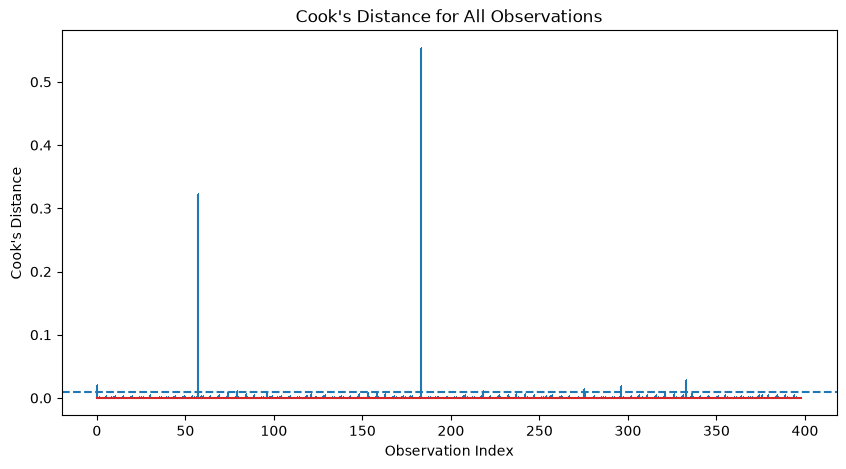

In [96]:
# Create a figure for visualising Cook's Distance
plt.figure(figsize=(10, 5))


# Plot Cook's Distance for each observation
# Each vertical line represents one observation
plt.stem(
    np.arange(len(cooks_distance)),
    cooks_distance,
    markerfmt=","
)


# Add the 4/n threshold as a horizontal reference line
plt.axhline(
    y=cooks_threshold,
    linestyle="--"
)


# Add a descriptive title
plt.title("Cook's Distance for All Observations")


# Label the horizontal axis
plt.xlabel("Observation Index")


# Label the vertical axis
plt.ylabel("Cook's Distance")


# Display the graph
plt.show()

In [97]:
# Find the row index of the observation with the smallest residual
# This corresponds to the most extreme negative prediction error

extreme_index = regression_diagnostics["Residual"].idxmin()


# Display detailed information for that observation
regression_diagnostics.loc[
    extreme_index,
    [
        "Order_ID",
        "Product_Category",
        "Shipping_Mode",
        "Order_Value",
        "Package_Weight_Kg",
        "Warehouse_Distance_Km",
        "Items_in_Order",
        "Warehouse_Processing_Hours",
        "Courier_Load_Index",
        "Traffic_Index",
        "Delivery_Time_Hours",
        "Predicted_Delivery_Time",
        "Residual",
        "Standardized_Residual",
        "Leverage",
        "Cooks_Distance"
    ]
]

Order_ID                        ORD100184
Product_Category              Electronics
Shipping_Mode                     Express
Order_Value                        6029.0
Package_Weight_Kg                    3.85
Warehouse_Distance_Km              1389.0
Items_in_Order                        1.0
Warehouse_Processing_Hours           3.11
Courier_Load_Index                   4.32
Traffic_Index                        5.54
Delivery_Time_Hours                 26.62
Predicted_Delivery_Time         80.490499
Residual                       -53.870499
Standardized_Residual           -11.89635
Leverage                         0.051919
Cooks_Distance                   0.553575
Name: 183, dtype: object

### Influential Observation Analysis

Standardized residuals, leverage values and Cook's Distance were examined
to determine whether potential outliers materially influenced the regression
model.

ORD100184 had a standardized residual of approximately -11.90 and a
Cook's Distance of approximately 0.554. Its actual delivery time was
26.62 hours compared with a model prediction of approximately 80.49 hours,
indicating an exceptionally large model residual.

ORD100058 had a leverage value of approximately 0.868 and a Cook's
Distance of approximately 0.323. The observation contained an unusually
high package weight of 59.2 kg and exerted substantial influence on the
estimated regression model.

ORD100330 also had high leverage because of its unusually large order value.
However, its Cook's Distance was very small, indicating that it did not
materially distort the fitted regression model.

Therefore, ORD100184 and ORD100058 were excluded from the corrected
regression analysis because of their exceptionally high influence.
ORD100330 was retained because high leverage alone does not justify
removing an observation when its influence on the fitted model is minimal.

In [110]:
# Create the final modelling dataset from df_clean
# df_clean already contains:
# - duplicate removal
# - standardised categorical values
# - impossible predictor values converted to NaN
# - missing target observation removed
#
# We create a new copy so df_clean remains unchanged.

df_model = df_clean.copy()


# Display the dataset dimensions before correcting data-entry outliers
print("Shape before data-entry correction:", df_model.shape)

Shape before data-entry correction: (399, 11)


In [111]:
# Display the three observations identified as factor-of-10
# data-entry anomalies before changing them
# This provides evidence of the original values in the notebook

df_model.loc[
    df_model["Order_ID"].isin([
        "ORD100058",
        "ORD100184",
        "ORD100330"
    ]),
    [
        "Order_ID",
        "Order_Value",
        "Package_Weight_Kg",
        "Warehouse_Distance_Km"
    ]
]

,Order_ID,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km
57,ORD100058,8008.0,59.20,218.7
183,ORD100184,6029.0,3.85,1389.0
329,ORD100330,68880.0,4.34,785.7


In [112]:
# Correct the Package_Weight_Kg data-entry error for ORD100058
# 59.2 kg becomes 5.92 kg by correcting the misplaced decimal/factor-of-10 error

df_model.loc[
    df_model["Order_ID"] == "ORD100058",
    "Package_Weight_Kg"
] = (
    df_model.loc[
        df_model["Order_ID"] == "ORD100058",
        "Package_Weight_Kg"
    ] / 10
)


# Correct the Warehouse_Distance_Km data-entry error for ORD100184
# 1389 km becomes 138.9 km

df_model.loc[
    df_model["Order_ID"] == "ORD100184",
    "Warehouse_Distance_Km"
] = (
    df_model.loc[
        df_model["Order_ID"] == "ORD100184",
        "Warehouse_Distance_Km"
    ] / 10
)


# Correct the Order_Value data-entry error for ORD100330
# 68880 becomes 6888

df_model.loc[
    df_model["Order_ID"] == "ORD100330",
    "Order_Value"
] = (
    df_model.loc[
        df_model["Order_ID"] == "ORD100330",
        "Order_Value"
    ] / 10
)

In [113]:
# Display the corrected observations
# This verifies that the intended factor-of-10 corrections were applied

df_model.loc[
    df_model["Order_ID"].isin([
        "ORD100058",
        "ORD100184",
        "ORD100330"
    ]),
    [
        "Order_ID",
        "Order_Value",
        "Package_Weight_Kg",
        "Warehouse_Distance_Km"
    ]
]

,Order_ID,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km
57,ORD100058,8008.0,5.92,218.7
183,ORD100184,6029.0,3.85,138.9
329,ORD100330,6888.0,4.34,785.7


In [114]:
# Create a separate dataset for the final Part A statistical-assumption check
# We do not use this imputed dataset for the final train-test model
# because final model imputation will happen inside the Pipeline

df_assumption_final = df_model.copy()


# Define the categorical predictors
categorical_columns = [
    "Product_Category",
    "Shipping_Mode"
]


# Impute missing categorical predictors with their most frequent category
# This is only for the full-sample Part A regression diagnostics

for column in categorical_columns:

    # Calculate the mode
    mode_value = df_assumption_final[column].mode()[0]

    # Replace the missing value
    df_assumption_final[column] = (
        df_assumption_final[column].fillna(mode_value)
    )

In [115]:
# Define all numerical predictor variables
numerical_columns_model = [
    "Order_Value",
    "Package_Weight_Kg",
    "Warehouse_Distance_Km",
    "Items_in_Order",
    "Warehouse_Processing_Hours",
    "Courier_Load_Index",
    "Traffic_Index"
]


# Temporarily impute missing numerical predictors with their median
# This allows us to re-check regression assumptions using a complete dataset

for column in numerical_columns_model:

    # Calculate the median
    median_value = df_assumption_final[column].median()

    # Replace missing observations with the median
    df_assumption_final[column] = (
        df_assumption_final[column].fillna(median_value)
    )

In [116]:
# Define the target variable for assumption testing
y_assumption = df_assumption_final["Delivery_Time_Hours"]


# Remove the identifier and target from the predictor dataset
X_assumption = df_assumption_final.drop(
    columns=[
        "Order_ID",
        "Delivery_Time_Hours"
    ]
)


# Convert nominal categorical predictors to dummy variables
# drop_first=True prevents the dummy-variable trap
X_assumption = pd.get_dummies(
    X_assumption,
    columns=[
        "Product_Category",
        "Shipping_Mode"
    ],
    drop_first=True,
    dtype=float
)


# Add the intercept required for statsmodels OLS
X_assumption_constant = sm.add_constant(X_assumption)


# Fit the corrected multiple linear regression model
final_assumption_model = sm.OLS(
    y_assumption,
    X_assumption_constant
).fit()


# Calculate the corrected residuals
final_assumption_residuals = final_assumption_model.resid


# Display the model summary
print(final_assumption_model.summary())

                             OLS Regression Results                            
Dep. Variable:     Delivery_Time_Hours   R-squared:                       0.934
Model:                             OLS   Adj. R-squared:                  0.932
Method:                  Least Squares   F-statistic:                     420.1
Date:                 Wed, 09 Sep 2026   Prob (F-statistic):          3.68e-218
Time:                         16:25:35   Log-Likelihood:                -1080.1
No. Observations:                  399   AIC:                             2188.
Df Residuals:                      385   BIC:                             2244.
Df Model:                           13                                         
Covariance Type:             nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------


In [117]:
# Re-check Durbin-Watson for independence of residuals
final_dw = durbin_watson(final_assumption_residuals)


# Re-check Breusch-Pagan for constant residual variance
final_bp = het_breuschpagan(
    final_assumption_residuals,
    X_assumption_constant
)


# Re-check Jarque-Bera for residual normality
final_jb = jarque_bera(final_assumption_residuals)


# Display the major assumption results
print("R-squared:", round(final_assumption_model.rsquared, 4))
print("Adjusted R-squared:", round(final_assumption_model.rsquared_adj, 4))
print("Durbin-Watson:", round(final_dw, 4))
print("Breusch-Pagan p-value:", round(final_bp[1], 4))
print("Jarque-Bera p-value:", round(final_jb[1], 4))
print("Residual Skewness:", round(final_jb[2], 4))
print("Residual Kurtosis:", round(final_jb[3], 4))

R-squared: 0.9341
Adjusted R-squared: 0.9319
Durbin-Watson: 2.0348
Breusch-Pagan p-value: 0.3103
Jarque-Bera p-value: 0.1705
Residual Skewness: 0.0558
Residual Kurtosis: 3.4476


In [118]:
# Create the predictor dataset for the final machine-learning model
# Order_ID is excluded because it is only an identifier
# Delivery_Time_Hours is excluded because it is the target

X = df_model.drop(
    columns=[
        "Order_ID",
        "Delivery_Time_Hours"
    ]
)


# Create the target/dependent variable
y = df_model["Delivery_Time_Hours"]


# Display the dimensions
print("Predictor dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Predictor dataset shape: (399, 9)
Target dataset shape: (399,)


In [119]:
# Define numerical predictor variables
# These will receive median imputation inside the Pipeline

numerical_features = [
    "Order_Value",
    "Package_Weight_Kg",
    "Warehouse_Distance_Km",
    "Items_in_Order",
    "Warehouse_Processing_Hours",
    "Courier_Load_Index",
    "Traffic_Index"
]


# Define categorical predictor variables
# These will receive mode imputation followed by one-hot encoding

categorical_features = [
    "Product_Category",
    "Shipping_Mode"
]

In [120]:
# Import train_test_split for separating training and testing observations
from sklearn.model_selection import train_test_split


# Split the dataset into:
# 80% training observations
# 20% testing observations
#
# random_state=42 makes the split reproducible
# so running the notebook again produces the same train-test division

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# Display the number of training and testing observations
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 319
Testing observations: 80


An 80:20 train-test split was used. Approximately 80% of the observations
were used to train the multiple linear regression model, while the remaining
20% were held out for evaluating its predictive performance. A random state
of 42 was used to ensure reproducibility.

In [121]:
# Import SimpleImputer for handling missing predictor values
from sklearn.impute import SimpleImputer


# Import Pipeline for combining preprocessing steps
from sklearn.pipeline import Pipeline


# Create the numerical preprocessing Pipeline
# Missing numerical values are replaced with the median calculated
# ONLY from the training dataset

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

In [122]:
# Import OneHotEncoder for converting nominal categories into dummy variables
from sklearn.preprocessing import OneHotEncoder


# Create the categorical preprocessing Pipeline
categorical_pipeline = Pipeline(
    steps=[

        # Replace missing categorical values using the most frequent
        # category learned from the training data
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        # Convert nominal categories into dummy variables
        # drop="first" removes one reference category
        # handle_unknown="ignore" prevents prediction errors
        # if the application encounters an unexpected category
        (
            "onehot",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            )
        )
    ]
)

In [123]:
# Import ColumnTransformer
# This allows different preprocessing steps to be applied
# to numerical and categorical variables

from sklearn.compose import ColumnTransformer


# Create the complete preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[

        # Apply numerical preprocessing to numerical features
        (
            "num",
            numerical_pipeline,
            numerical_features
        ),

        # Apply categorical preprocessing to categorical features
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [124]:
# Import the LinearRegression algorithm
from sklearn.linear_model import LinearRegression


# Create one complete Pipeline containing:
# Step 1: preprocessing
# Step 2: multiple linear regression

model_pipeline = Pipeline(
    steps=[

        # Perform all required preprocessing
        (
            "preprocessor",
            preprocessor
        ),

        # Fit the multiple linear regression model
        (
            "regressor",
            LinearRegression()
        )
    ]
)

In [125]:
# Fit the complete Pipeline using ONLY the training observations
# The imputers, one-hot encoder and regression coefficients
# are all learned from X_train and y_train

model_pipeline.fit(
    X_train,
    y_train
)


# Confirm that model training has completed
print("Multiple Linear Regression model trained successfully.")

Multiple Linear Regression model trained successfully.


In [126]:
# Predict delivery times for the training observations
# These predictions are useful for evaluating training fit

y_train_pred = model_pipeline.predict(X_train)


# Predict delivery times for the unseen test observations
# These predictions are used for final predictive evaluation

y_test_pred = model_pipeline.predict(X_test)

In [127]:
# Import regression evaluation metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)


# Calculate training R-squared
# This shows how much variation in the training target is explained
train_r2 = r2_score(
    y_train,
    y_train_pred
)


# Calculate test R-squared
# This evaluates explanatory/predictive performance on unseen observations
test_r2 = r2_score(
    y_test,
    y_test_pred
)


# Display both values
print("Training R-squared:", round(train_r2, 4))
print("Testing R-squared:", round(test_r2, 4))

Training R-squared: 0.9358
Testing R-squared: 0.9078


In [128]:
# Transform the training dataset using the fitted preprocessor
# This lets us determine the actual number of predictors
# after one-hot encoding

X_train_transformed = (
    model_pipeline
    .named_steps["preprocessor"]
    .transform(X_train)
)


# n = number of training observations
n_train = len(y_train)


# p = number of predictors after preprocessing
p = X_train_transformed.shape[1]


# Calculate Adjusted R-squared
# This penalises R-squared for the number of predictors used

train_adjusted_r2 = (
    1
    -
    (
        (1 - train_r2) * (n_train - 1)
        /
        (n_train - p - 1)
    )
)


# Display the number of final predictors and Adjusted R-squared
print("Number of transformed predictors:", p)
print(
    "Training Adjusted R-squared:",
    round(train_adjusted_r2, 4)
)

Number of transformed predictors: 13
Training Adjusted R-squared: 0.933


In [129]:
# Calculate Mean Absolute Error
# This gives the average absolute prediction error in HOURS

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)


# Calculate Mean Squared Error
# This penalises larger prediction errors more heavily

test_mse = mean_squared_error(
    y_test,
    y_test_pred
)


# Calculate Root Mean Squared Error
# RMSE converts MSE back into HOURS

test_rmse = np.sqrt(test_mse)


# Display all final test-set metrics
print("Test R-squared:", round(test_r2, 4))
print("Test MAE:", round(test_mae, 4), "hours")
print("Test MSE:", round(test_mse, 4))
print("Test RMSE:", round(test_rmse, 4), "hours")

Test R-squared: 0.9078
Test MAE: 3.4089 hours
Test MSE: 17.9059
Test RMSE: 4.2315 hours


In [130]:
# Create a compact model-evaluation table
# This is useful for displaying the final results in the notebook/report

evaluation_table = pd.DataFrame({
    "Metric": [
        "Training R-squared",
        "Training Adjusted R-squared",
        "Testing R-squared",
        "Testing MAE (Hours)",
        "Testing MSE",
        "Testing RMSE (Hours)"
    ],

    "Value": [
        train_r2,
        train_adjusted_r2,
        test_r2,
        test_mae,
        test_mse,
        test_rmse
    ]
})


# Round values for easier presentation
evaluation_table["Value"] = (
    evaluation_table["Value"].round(4)
)


# Display the table
evaluation_table

,Metric,Value
0,Training R-squared,0.9358
1,Training Adjusted R-squared,0.9330
2,Testing R-squared,0.9078
3,Testing MAE (Hours),3.4089
4,Testing MSE,17.9059
5,Testing RMSE (Hours),4.2315


In [131]:
# Calculate residuals for the unseen test observations
# Residual = Actual Delivery Time - Predicted Delivery Time

test_residuals = (
    y_test - y_test_pred
)

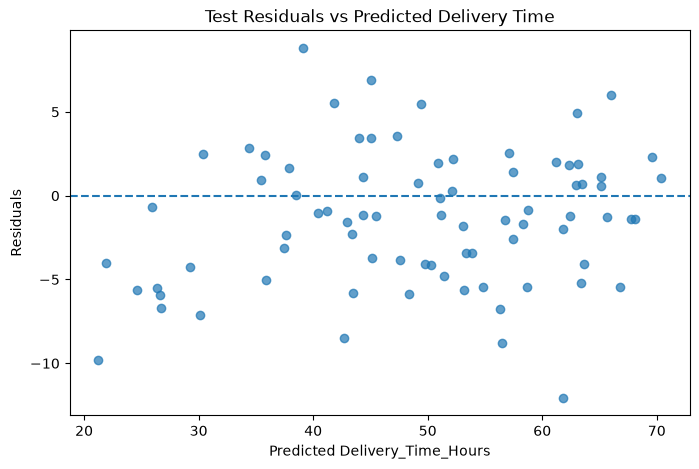

In [132]:
# Create a residual-versus-predicted plot for the test observations
# This helps identify systematic prediction patterns in unseen data

plt.figure(figsize=(8, 5))


# Plot predicted delivery times against residuals
plt.scatter(
    y_test_pred,
    test_residuals,
    alpha=0.7
)


# Add a horizontal reference line at residual = 0
plt.axhline(
    y=0,
    linestyle="--"
)


# Add labels and title
plt.title("Test Residuals vs Predicted Delivery Time")
plt.xlabel("Predicted Delivery_Time_Hours")
plt.ylabel("Residuals")


# Display the graph
plt.show()

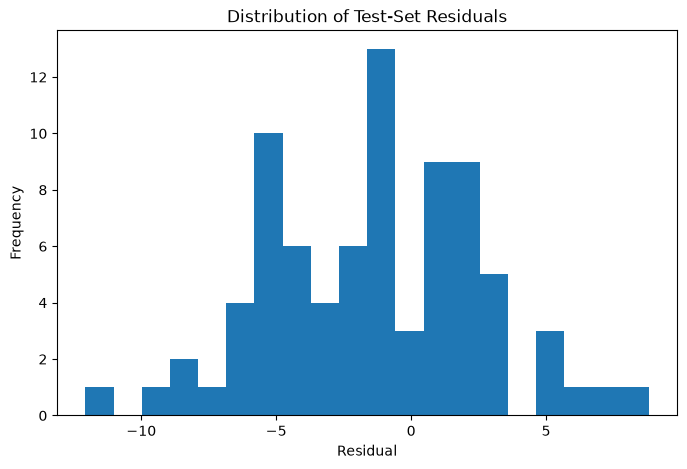

In [133]:
# Plot the distribution of test-set residuals
# This helps inspect whether prediction errors are approximately symmetric

plt.figure(figsize=(8, 5))


# Create the histogram
plt.hist(
    test_residuals,
    bins=20
)


# Add labels and title
plt.title("Distribution of Test-Set Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")


# Display the graph
plt.show()

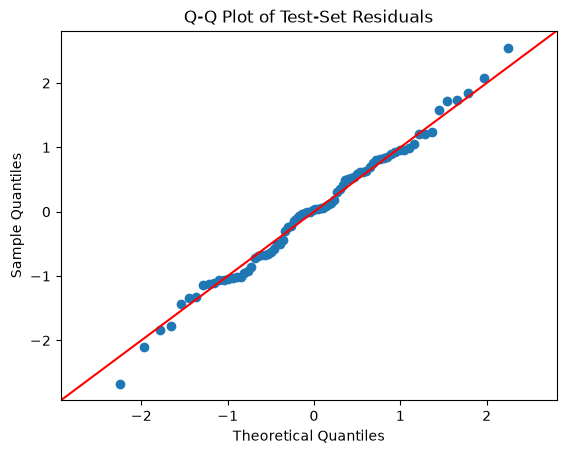

In [134]:
# Create a Q-Q plot of test residuals
# This provides an additional visual check of residual normality

sm.qqplot(
    test_residuals,
    line="45",
    fit=True
)


# Add a descriptive title
plt.title("Q-Q Plot of Test-Set Residuals")


# Display the graph
plt.show()

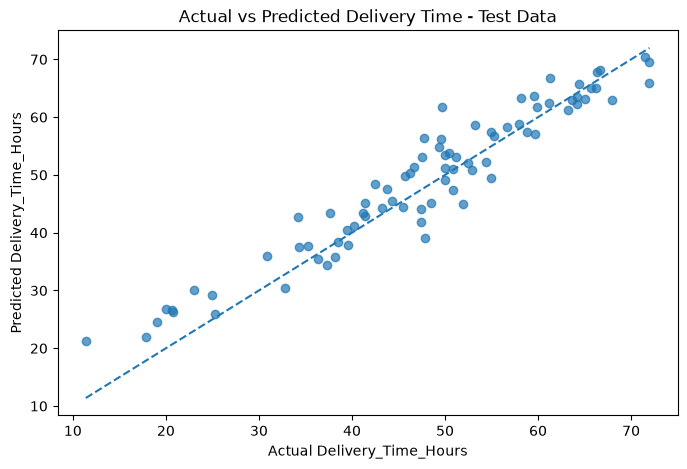

In [135]:
# Create a graph comparing actual test delivery times
# with the model's predicted delivery times

plt.figure(figsize=(8, 5))


# Plot actual values against predictions
plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.7
)


# Add the ideal prediction line
# Perfect predictions would lie directly on this line

minimum_value = min(
    y_test.min(),
    y_test_pred.min()
)

maximum_value = max(
    y_test.max(),
    y_test_pred.max()
)


plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)


# Add labels
plt.title("Actual vs Predicted Delivery Time - Test Data")
plt.xlabel("Actual Delivery_Time_Hours")
plt.ylabel("Predicted Delivery_Time_Hours")


# Display the graph
plt.show()

In [136]:
# Extract the final feature names created by the preprocessing Pipeline
# This includes numerical variables and one-hot encoded categories

feature_names = (
    model_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)


# Extract the regression coefficients
coefficients = (
    model_pipeline
    .named_steps["regressor"]
    .coef_
)


# Create a coefficient table
coefficient_table_final = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})


# Remove technical ColumnTransformer prefixes
# to make the variable names easier to read

coefficient_table_final["Feature"] = (
    coefficient_table_final["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)


# Display coefficients
coefficient_table_final

,Feature,Coefficient
0,Order_Value,0.000042
1,Package_Weight_Kg,0.281019
2,Warehouse_Distance_Km,0.042002
3,Items_in_Order,0.597539
4,Warehouse_Processing_Hours,1.260023
5,Courier_Load_Index,1.002622
6,Traffic_Index,1.312822
7,Product_Category_Books,0.556436
8,Product_Category_Electronics,0.361992
9,Product_Category_Fashion,-0.662303


In [137]:
# Extract and display the regression intercept

final_intercept = (
    model_pipeline
    .named_steps["regressor"]
    .intercept_
)


print(
    "Regression Intercept:",
    round(final_intercept, 4)
)

Regression Intercept: 7.8006


In [138]:
# Access the fitted OneHotEncoder inside the categorical Pipeline

fitted_encoder = (
    model_pipeline
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
)


# Display the categories learned for each categorical variable
# Because drop="first" is used, the first category shown for each
# variable becomes its reference category

for feature, categories in zip(
    categorical_features,
    fitted_encoder.categories_
):

    print(
        feature,
        "categories:",
        categories
    )

    print(
        feature,
        "reference category:",
        categories[0]
    )

    print()

Product_Category categories: ['Beauty' 'Books' 'Electronics' 'Fashion' 'Home & Kitchen']
Product_Category reference category: Beauty

Shipping_Mode categories: ['Express' 'Same-Day' 'Standard']
Shipping_Mode reference category: Express



In [139]:
# Import clone so we can create a fresh copy of the evaluated Pipeline
from sklearn.base import clone


# Create a separate final deployment Pipeline
# This prevents us from overwriting the train-test evaluation model

deployment_pipeline = clone(model_pipeline)


# Fit the final deployment model using all available cleaned observations
# The train-test model has already been evaluated above
# This version is trained on all available data for use in the web application

deployment_pipeline.fit(
    X,
    y
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Product_Category','Shipping_Mode','Order_Value',..., 'Warehouse_Processing_Hours','Courier_Load_Index','Traffic_Index']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be 

In [140]:
# Import joblib for saving the complete trained Pipeline
import joblib


# Save preprocessing + linear regression together in one .pkl file
# The web application will later load this file directly

joblib.dump(
    deployment_pipeline,
    "model.pkl"
)


# Confirm that the model file has been created
print("model.pkl saved successfully.")

model.pkl saved successfully.


In [141]:
# Load the saved model back into Python
# This checks that the .pkl file is valid before building the web application

loaded_model = joblib.load(
    "model.pkl"
)


# Generate one prediction using the reloaded model
# If this works, the preprocessing and regression model were saved correctly

test_saved_prediction = loaded_model.predict(
    X.head(1)
)


# Display the prediction
print(
    "Test prediction from loaded model:",
    test_saved_prediction
)

Test prediction from loaded model: [20.9281845]


In [144]:
# Install Streamlit in the same Python environment being used by Jupyter
# This package is required to create and run the interactive web application

%pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [145]:
# Import Streamlit to confirm that it is installed correctly
import streamlit as st

# Display the installed Streamlit version
print("Streamlit version:", st.__version__)

Streamlit version: 1.58.0


In [146]:
%%writefile app.py

# Import Streamlit for creating the interactive web application
import streamlit as st

# Import pandas for creating the single-row DataFrame
# that will be passed to the trained model
import pandas as pd

# Import joblib for loading the saved preprocessing + regression Pipeline
import joblib

# Import Path so the application can reliably locate model.pkl
# in the same folder as app.py
from pathlib import Path


# ---------------------------------------------------------
# PAGE CONFIGURATION
# ---------------------------------------------------------

# Configure the browser tab and application layout
st.set_page_config(
    page_title="E-Commerce Delivery Time Predictor",
    page_icon="📦",
    layout="centered"
)


# ---------------------------------------------------------
# LOAD THE TRAINED MODEL
# ---------------------------------------------------------

# Identify the folder in which app.py is located
BASE_DIR = Path(__file__).resolve().parent

# Create the full path to the saved model
MODEL_PATH = BASE_DIR / "model.pkl"


# Attempt to load the saved preprocessing + regression Pipeline
# If model.pkl cannot be found or loaded, the application stops
# and shows a clear error message instead of crashing silently
try:
    model = joblib.load(MODEL_PATH)

except Exception as error:

    # Display the error to the user
    st.error(
        f"The trained model could not be loaded: {error}"
    )

    # Stop the application because predictions cannot be made
    st.stop()


# ---------------------------------------------------------
# APPLICATION HEADER
# ---------------------------------------------------------

# Display the application title
st.title("📦 E-Commerce Delivery Time Predictor")


# Explain the purpose of the application
st.write(
    """
    This application uses a multiple linear regression model to estimate
    the delivery time of an e-commerce order based on order, package,
    warehouse, courier, traffic and shipping characteristics.
    """
)


# Add a visual separator
st.divider()


# ---------------------------------------------------------
# INPUT SECTION
# ---------------------------------------------------------

# Display a heading above the user input fields
st.subheader("Order and Delivery Information")


# Create two columns so that the application is easier to use
left_column, right_column = st.columns(2)


# ---------------------------------------------------------
# LEFT-SIDE INPUTS
# ---------------------------------------------------------

with left_column:

    # Allow the user to select one of the five valid product categories
    # These values come from the dataset specification
    product_category = st.selectbox(
        "Product Category",
        [
            "Electronics",
            "Fashion",
            "Home & Kitchen",
            "Beauty",
            "Books"
        ]
    )


    # Allow the user to select one of the three valid shipping modes
    # These values match the categories used during model training
    shipping_mode = st.selectbox(
        "Shipping Mode",
        [
            "Standard",
            "Express",
            "Same-Day"
        ]
    )


    # Accept a positive monetary order value
    # The data dictionary states that Order_Value must be greater than zero
    order_value = st.number_input(
        "Order Value (₹)",
        min_value=0.01,
        value=6000.00,
        step=100.00
    )


    # Accept a positive package weight
    # Package weight cannot logically be zero or negative
    package_weight = st.number_input(
        "Package Weight (kg)",
        min_value=0.01,
        value=3.00,
        step=0.10
    )


    # Accept a positive warehouse-to-destination distance
    warehouse_distance = st.number_input(
        "Warehouse Distance (km)",
        min_value=0.01,
        value=400.00,
        step=10.00
    )


# ---------------------------------------------------------
# RIGHT-SIDE INPUTS
# ---------------------------------------------------------

with right_column:

    # Items_in_Order has a valid range of 1 to 10
    # Therefore the interface does not allow values outside that range
    items_in_order = st.number_input(
        "Items in Order",
        min_value=1,
        max_value=10,
        value=4,
        step=1
    )


    # Warehouse processing time must be positive
    warehouse_processing_hours = st.number_input(
        "Warehouse Processing Time (Hours)",
        min_value=0.01,
        value=3.00,
        step=0.10
    )


    # Courier_Load_Index has a valid range of 1 to 10
    courier_load_index = st.number_input(
        "Courier Load Index",
        min_value=1.0,
        max_value=10.0,
        value=5.0,
        step=0.1
    )


    # Traffic_Index also has a valid range of 1 to 10
    traffic_index = st.number_input(
        "Traffic Index",
        min_value=1.0,
        max_value=10.0,
        value=5.0,
        step=0.1
    )


# ---------------------------------------------------------
# TYPICAL-RANGE WARNINGS
# ---------------------------------------------------------

# The data dictionary states that Order_Value is typically
# between ₹300 and ₹15,000.
# These are not strict validity limits, so the application shows
# a warning rather than rejecting values outside this range.
if order_value < 300 or order_value > 15000:
    st.warning(
        "Order Value is outside the dataset's typical range of ₹300–₹15,000."
    )


# Package weight is typically between 0.1 and 15 kg
if package_weight < 0.1 or package_weight > 15:
    st.warning(
        "Package Weight is outside the dataset's typical range of 0.1–15 kg."
    )


# Warehouse distance is typically between 15 and 950 km
if warehouse_distance < 15 or warehouse_distance > 950:
    st.warning(
        "Warehouse Distance is outside the dataset's typical range of 15–950 km."
    )


# Warehouse processing time is typically between 0.5 and 6 hours
if (
    warehouse_processing_hours < 0.5
    or warehouse_processing_hours > 6
):
    st.warning(
        "Warehouse Processing Time is outside the dataset's typical range of 0.5–6 hours."
    )


# ---------------------------------------------------------
# CREATE MODEL INPUT
# ---------------------------------------------------------

# Create a single-row DataFrame using EXACTLY the same predictor names
# that were used while training the saved preprocessing Pipeline
input_data = pd.DataFrame(
    {
        "Product_Category": [product_category],
        "Shipping_Mode": [shipping_mode],
        "Order_Value": [order_value],
        "Package_Weight_Kg": [package_weight],
        "Warehouse_Distance_Km": [warehouse_distance],
        "Items_in_Order": [items_in_order],
        "Warehouse_Processing_Hours": [
            warehouse_processing_hours
        ],
        "Courier_Load_Index": [courier_load_index],
        "Traffic_Index": [traffic_index]
    }
)


# ---------------------------------------------------------
# PREDICTION
# ---------------------------------------------------------

# Add some spacing before the prediction section
st.divider()


# Create a button so that the prediction is only generated
# when the user explicitly requests it
if st.button(
    "Predict Delivery Time",
    type="primary",
    use_container_width=True
):

    # Pass the user's inputs through the saved preprocessing
    # and multiple linear regression Pipeline
    prediction = model.predict(input_data)[0]


    # Prevent a negative prediction from being presented as a valid
    # business result because delivery time cannot logically be negative
    if prediction <= 0:

        st.error(
            "The model generated an invalid non-positive delivery-time estimate. "
            "Please review the entered values."
        )

    else:

        # Display the prediction clearly in HOURS,
        # which is the unit of the target variable
        st.metric(
            label="Predicted Delivery Time",
            value=f"{prediction:.2f} hours"
        )


        # Provide a short managerial interpretation,
        # as specifically required by the assignment
        st.info(
            f"""
            Based on the entered order and operational conditions,
            the model estimates that the order will require approximately
            **{prediction:.2f} hours** for delivery.

            A manager can use this estimate for delivery planning,
            operational coordination and customer expectation management.
            """
        )


# ---------------------------------------------------------
# MODEL INFORMATION
# ---------------------------------------------------------

# Add another separator before the explanatory section
st.divider()


# Provide a short explanation of the underlying model
with st.expander("About the Prediction Model"):

    st.write(
        """
        The prediction is generated using a Multiple Linear Regression model.

        The model uses the following predictor information:

        - Product category
        - Shipping mode
        - Order value
        - Package weight
        - Warehouse distance
        - Number of items in the order
        - Warehouse processing time
        - Courier load index
        - Traffic index

        Order_ID is not used because it is only an identifier and does not
        represent a meaningful explanatory variable.
        """
    )

Writing app.py


In [147]:
# Import os for checking files in the current project folder
import os


# Display all files in the current working directory
# Confirm that both app.py and model.pkl appear in this list
os.listdir()

['.ipynb_checkpoints',
 'app.py',
 'Assignment 2.pdf',
 'ecommerce_delivery_unclean_data.csv',
 'ecommerce_delivery_unclean_dataset_reference.xlsx',
 'model.pkl',
 'model_training.ipynb']

In [148]:
# Import os so we can identify the folder containing
# model.pkl, app.py and the Jupyter notebook
import os

# Display the current project folder path
print(os.getcwd())

C:\Users\VISHAL\Desktop\AISPP ASSIGNMENT


In [150]:
# Import sys to identify the exact Python version used
# to train and save model.pkl
import sys

# Import all important libraries used by the deployed model
import streamlit
import pandas
import numpy
import sklearn
import scipy
import joblib
import threadpoolctl


# Display the exact Python version
# We will use the same major/minor version on Streamlit Cloud
print("Python version:", sys.version)

# Display only the major/minor version for easier deployment setup
print(
    "Python major/minor:",
    f"{sys.version_info.major}.{sys.version_info.minor}"
)


# Display exact package versions
# These versions should be reproduced in the cloud environment
print("Streamlit:", streamlit.__version__)
print("Pandas:", pandas.__version__)
print("NumPy:", numpy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)
print("Joblib:", joblib.__version__)
print("Threadpoolctl:", threadpoolctl.__version__)

Python version: 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
Python major/minor: 3.14
Streamlit: 1.58.0
Pandas: 3.0.3
NumPy: 2.4.6
Scikit-learn: 1.9.0
SciPy: 1.18.0
Joblib: 1.5.3
Threadpoolctl: 3.5.0


In [151]:
# Create a minimal requirements.txt using the exact package versions
# from the environment in which model.pkl was created
#
# This reduces the chance of model.pkl failing to load
# because of package-version differences on Streamlit Cloud

requirements = [
    f"streamlit=={streamlit.__version__}",
    f"pandas=={pandas.__version__}",
    f"numpy=={numpy.__version__}",
    f"scikit-learn=={sklearn.__version__}",
    f"scipy=={scipy.__version__}",
    f"joblib=={joblib.__version__}",
    f"threadpoolctl=={threadpoolctl.__version__}"
]


# Open/create requirements.txt in the current project folder
with open(
    "requirements.txt",
    "w",
    encoding="utf-8"
) as file:

    # Write one dependency per line
    file.write("\n".join(requirements))


# Confirm that the file was created successfully
print("requirements.txt created successfully.")

# Display its contents so we can verify it
with open(
    "requirements.txt",
    "r",
    encoding="utf-8"
) as file:

    print(file.read())

requirements.txt created successfully.
streamlit==1.58.0
pandas==3.0.3
numpy==2.4.6
scikit-learn==1.9.0
scipy==1.18.0
joblib==1.5.3
threadpoolctl==3.5.0


In [152]:
# Import os for creating a folder to store
# screenshots of the working web application
import os


# Create a screenshots folder
# exist_ok=True prevents an error if it already exists
os.makedirs(
    "screenshots",
    exist_ok=True
)


# Confirm that the folder exists
print(
    "Screenshots folder created:",
    os.path.exists("screenshots")
)

Screenshots folder created: True


app_inputs.png
app_prediction.png

In [153]:
%%writefile README.md
# E-Commerce Delivery Time Prediction

## Project Overview

This project develops a Multiple Linear Regression model to estimate the
delivery time of an e-commerce order.

The project covers the complete workflow from raw business data to a
deployed prediction application, including data-quality assessment,
regression-assumption diagnostics, model training, evaluation, model
persistence, and deployment using Streamlit.

## Business Problem

Accurate delivery-time estimation can support e-commerce managers in
delivery planning, operational coordination, logistics management, and
customer expectation management.

The model predicts:

**Delivery_Time_Hours**

## Dataset

The dataset contains e-commerce order and operational characteristics.

### Predictor Variables

The model uses the following predictors:

- Product_Category
- Shipping_Mode
- Order_Value
- Package_Weight_Kg
- Warehouse_Distance_Km
- Items_in_Order
- Warehouse_Processing_Hours
- Courier_Load_Index
- Traffic_Index

`Order_ID` is retained as an identifier during data analysis but is not
used as a regression predictor.

## Data Preparation

The data-preparation workflow includes:

- Missing-value analysis and treatment
- Duplicate detection and removal
- Standardisation of inconsistent categorical values
- Identification and correction of impossible values
- Investigation of data-entry errors
- Outlier analysis using the IQR method
- Investigation of influential observations using standardized residuals,
  leverage, and Cook's Distance

## Linear Regression Assumptions

The following assumptions and diagnostics were examined:

- Linearity
- Multicollinearity using correlation analysis and VIF
- Independence of errors using the Durbin-Watson statistic
- Homoscedasticity using residual-versus-fitted analysis and the
  Breusch-Pagan test
- Normality of residuals using histogram, Q-Q plot and Jarque-Bera test
- Outlier and influence analysis using IQR, standardized residuals,
  leverage and Cook's Distance

After corrective treatment, the regression model was re-fitted and the
major assumptions were re-checked.

## Model Development

Multiple Linear Regression was used as the primary predictive model.

An 80:20 train-test split was used for predictive evaluation.

The final machine-learning workflow uses a scikit-learn Pipeline so that
the same preprocessing steps are applied during both training and
prediction.

### Numerical Preprocessing

Missing numerical predictor values are imputed using the median.

### Categorical Preprocessing

Missing categorical values are imputed using the most frequent category.

Nominal categorical predictors are converted using one-hot encoding.

## Model Evaluation

The model is evaluated using:

- R-squared
- Adjusted R-squared
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Residual analysis

The detailed model results and diagnostic outputs are available in
`model_training.ipynb`.

## Saved Model

The complete preprocessing and Multiple Linear Regression Pipeline is
saved as:

`model.pkl`

The Streamlit application loads this saved Pipeline directly and does not
retrain the model when the application starts.

## Web Application

The Streamlit application allows users to enter:

- Product category
- Shipping mode
- Order value
- Package weight
- Warehouse distance
- Number of items
- Warehouse processing time
- Courier load index
- Traffic index

The application then displays the estimated delivery time in hours and
provides a short managerial interpretation.

## Application Screenshots

### Input Interface

![Application Input Interface](screenshots/app_inputs.png)

### Prediction Output

![Application Prediction Output](screenshots/app_prediction.png)

## Project Structure

```text
project/
│
├── ecommerce_delivery_unclean_data.csv
├── model_training.ipynb
├── model.pkl
├── app.py
├── requirements.txt
├── README.md
│
└── screenshots/
    ├── app_inputs.png
    └── app_prediction.png

Writing README.md


In [154]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.
